# Student A — Content / NLP Phishing Detector

**Course:** Data Science & Cyber · **Part:** Student A (email *content* analysis)

This notebook builds a text-only phishing detector and studies three things the
lecturer asked for: **detection** (how well text separates phishing from
legitimate mail), **explainability** (which words drove a decision), and — the
main focus — **adversarial robustness** (what happens when an attacker obfuscates
the text with homoglyphs / leetspeak, and how a normalisation defence holds up).

It is organised around four research questions:

* **RQ1 — Signal.** How well does a TF-IDF + Naive-Bayes / Logistic-Regression
  model separate phishing from legitimate email, on a single confound-free corpus?
* **RQ2 — Robustness.** How much does character-level obfuscation degrade the
  detector, and how much do normalisation and character n-grams recover — including
  against attacks the defence was *not* designed for?
* **RQ3 — Transfer.** Do attacks crafted against the lexical model also hurt
  DistilBERT?
* **RQ4 — Trade-off.** What does robustness cost us in interpretability?

Everything is reproducible: fixed seeds, a single configuration block, and all
tables/figures written to `results/`.

### How to read this notebook

It runs top to bottom: Run All and every table and figure below is rebuilt from the raw data.

Each section is laid out the same way: a short note on what it does and why, then the code, then its
output, then a line or two on what the result means.

Sections 1--12 build the detector and measure it. Sections 13--28 are the core of the project: I
attack the detector and then try to fix it, one round after another. Sections 29--30 save the
predictions for the fusion step and pull the headline numbers together.

Short on time? Look at section 13 (the first attack and defence), 21--22 (the principled fix and the
guarantee that comes with it), and 25--28 (real 2023--2025 scams, and retraining the model to keep up).

## 0. Configuration

Everything a reader might want to change lives here (paths, column names, seeds,
feature sizes). The defaults mirror `src/config.py`; edit either place.

In [1]:
import os, sys, time, warnings, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# make the local src/ package importable when the notebook runs from notebooks/
ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src import config as C
from src import data as D, normalize as NORM, attacks as ATK, stats as ST, explain as EXP

# ---- knobs (editable) ------------------------------------------------------
DATA_FILE      = C.RAW_DIR / "CEAS_08.csv"   # primary, mixed-class corpus
LABEL_COL      = C.LABEL_COL                 # 1 = phishing, 0 = legit
PHISH_FRACTION = C.PHISH_FRACTION            # realistic legit-majority base rate
SEED           = C.RANDOM_SEED
RUN_BERT       = os.environ.get("PHISH_RUN_BERT", "1") == "1"   # set 0 to skip DistilBERT
BERT_N_TRAIN   = 3000                        # subset size for the CPU fine-tune (bounded; [P5] bumped)

np.random.seed(SEED)
plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 11})
GREEN, RED, BLUE, GREY = "#2a9d8f", "#e76f51", "#264653", "#8d99ae"

TABLES, FIGS = C.TABLES_DIR, C.FIGURES_DIR
def save_table(df, name):
    df.to_csv(TABLES / f"{name}.csv")
    return df
def savefig(name):
    plt.savefig(FIGS / f"{name}.png", dpi=120, bbox_inches="tight")
def ci_str(point, lo, hi):
    return f"{point:.3f} [{lo:.3f}, {hi:.3f}]"
print("project root:", ROOT)
print("outputs ->", TABLES, "and", FIGS)

project root: C:\GitHub\Data_Science\PhishFusion
outputs -> C:\GitHub\Data_Science\PhishFusion\results\tables and C:\GitHub\Data_Science\PhishFusion\results\figures


## 1. Data — loading, cleaning and a realistic base rate

We use the **CEAS_08** corpus from the Kaggle "Phishing Email Dataset" compilation.
Of all the corpora in that pack it is the only large one that contains **both
phishing and legitimate email from the same source**, which matters: if phishing
and ham came from *different* corpora, a model could score well just by learning
"which corpus is this" instead of "is this phishing". CEAS_08 removes that
confound by construction (we verify the confound directly in §3).

Two cleaning choices are deliberate:

1. **URLs are stripped** from the text (replaced by a `URL` token). Links are the
   partner detector's job (Student B); a *content* model should not secretly ride
   on them.
2. **We rebalance to a legit-majority base rate** (`PHISH_FRACTION = 0.35`). Real
   inboxes are mostly legitimate, and — as we will see in §13 — a phishing-majority
   prior hides evasion attacks, because a model that loses its signal falls back to
   the majority class.

In [2]:
raw = D.load_corpus(DATA_FILE.name)
print(f"raw CEAS_08: {len(raw):,} emails, {raw.label.mean():.1%} phishing")

# subsample phishing down to a legit-majority prior
ham = raw[raw.label == 0]
phi = raw[raw.label == 1]
n_phi = int(len(ham) * PHISH_FRACTION / (1 - PHISH_FRACTION))
phi = phi.sample(n=min(n_phi, len(phi)), random_state=SEED)
df = pd.concat([ham, phi]).sample(frac=1, random_state=SEED).reset_index(drop=True)
df["text"] = D.make_text(df)
df["id"] = np.arange(len(df))

# freeze a reproducible snapshot + hash
df.to_csv(C.DATA_DIR / "emails_working.csv", index=False)
DATA_SHA = D.sha256_of(C.DATA_DIR / "emails_working.csv")
print(f"working set: {len(df):,} emails, {df.label.mean():.1%} phishing")
print("SHA-256:", DATA_SHA[:16], "...")
(TABLES / "data_hash.txt").write_text(f"emails_working.csv rows={len(df)} sha256={DATA_SHA}\n")
df.sample(3, random_state=1)[["source", "subject", "label"]]

raw CEAS_08: 39,154 emails, 55.8% phishing


working set: 26,633 emails, 35.0% phishing
SHA-256: f55ba2a4f058567f ...


,source,subject,label
12427,CEAS_08,Re: sitecustomize.pl pollutes tests,0
5761,CEAS_08,Your own business!,1
9825,CEAS_08,Re: [Python-Dev] [Distutils] How we can get ri...,0


### 🔎 Analysis of the results

The rebalancing did what we wanted: legitimate mail is now the majority and phishing the minority, which mirrors a real inbox far better than the raw corpus (where phishing was actually the larger class). Two consequences carry through the whole notebook. First, because we kept a *single* corpus, any score the model earns has to come from phishing-ness, not from telling corpora apart. Second, the phishing share is a **knob, not a fact of nature** — so the headline metrics should always be read together with this base rate; the same model on a differently balanced set would move the numbers even though the model itself is unchanged.

### Data inspection

A quick look at the shape, column types and index before any analysis: do the
columns make sense, is anything constant or duplicated, and what time span does the
corpus cover?

In [3]:
print("shape:", df.shape)
print("columns:", list(df.columns))
print("\ndtypes:")
print(df[["source", "date", "subject", "body", "label"]].dtypes.to_string())

# CEAS ships a real 'date' header; parse it to see the time span.
dts = pd.to_datetime(df["date"], errors="coerce", utc=True)
print(f"\ndate: {dts.notna().mean():.0%} parseable, span {dts.min()} -> {dts.max()}")
print("duplicate texts:", int(df.duplicated("text").sum()))
print("constant (single-value) columns:", [c for c in df.columns if df[c].nunique() <= 1])
print("label values:", sorted(df.label.unique()), "(1 = phishing, 0 = legit)")

shape: (26633, 7)
columns: ['source', 'date', 'subject', 'body', 'label', 'text', 'id']

dtypes:
source     object
date       object
subject    object
body       object
label       int64



date: 100% parseable, span 1981-10-07 11:41:34+00:00 -> 2100-05-27 19:54:05+00:00
duplicate texts: 1919
constant (single-value) columns: ['source']
label values: [np.int64(0), np.int64(1)] (1 = phishing, 0 = legit)


## 2. Exploratory data analysis

Before modelling we check the basics: class balance, e-mail length, empty/duplicate
rows, and — a foreshadowing of the attack section — how much non-ASCII text is
normally present (so we know what "clean" looks like before an attacker starts
injecting look-alike characters).

missing/empty subject: 23 | empty body: 0 | duplicates on text: 1919


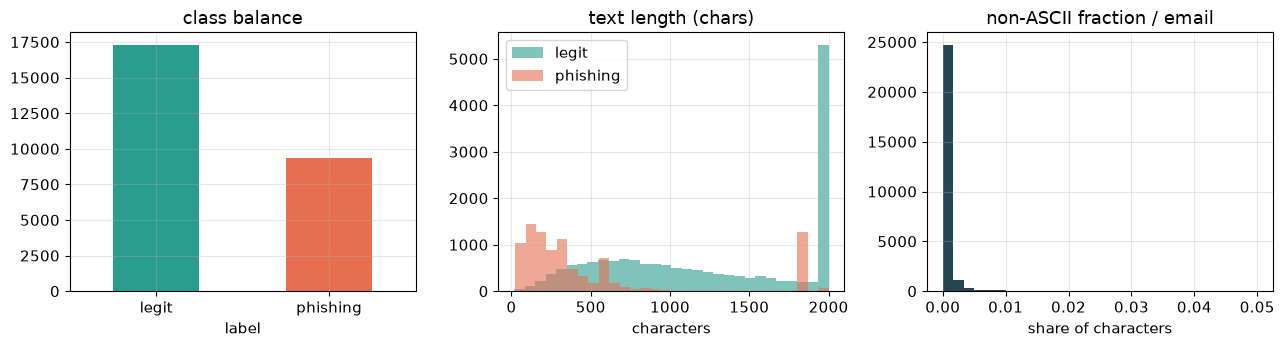

median non-ASCII share: 0.0000 (clean mail is almost all ASCII)


In [4]:
print("missing/empty subject:", int((df.subject.str.len() == 0).sum()),
      "| empty body:", int((df.body.str.len() == 0).sum()),
      "| duplicates on text:", int(df.duplicated("text").sum()))

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
df.label.map({0: "legit", 1: "phishing"}).value_counts().plot.bar(
    ax=ax[0], color=[GREEN, RED], rot=0); ax[0].set_title("class balance")

for lab, clr in [(0, GREEN), (1, RED)]:
    ax[1].hist(df[df.label == lab].text.str.len().clip(upper=2000),
               bins=30, alpha=.6, color=clr, label=["legit", "phishing"][lab])
ax[1].set_title("text length (chars)"); ax[1].set_xlabel("characters"); ax[1].legend()

# non-ASCII share per email (baseline for the homoglyph attack later)
nonascii = df.text.map(lambda s: sum(ord(c) > 127 for c in s) / max(len(s), 1))
ax[2].hist(nonascii.clip(upper=0.05), bins=30, color=BLUE)
ax[2].set_title("non-ASCII fraction / email"); ax[2].set_xlabel("share of characters")
plt.tight_layout(); savefig("F1_eda"); plt.show()
print(f"median non-ASCII share: {nonascii.median():.4f} (clean mail is almost all ASCII)")

Next, the most **discriminative** tokens per class — a log-odds score, so a word
scores high only if it is both frequent *and* lopsided towards one class. This is a
sanity check that the labels make sense.

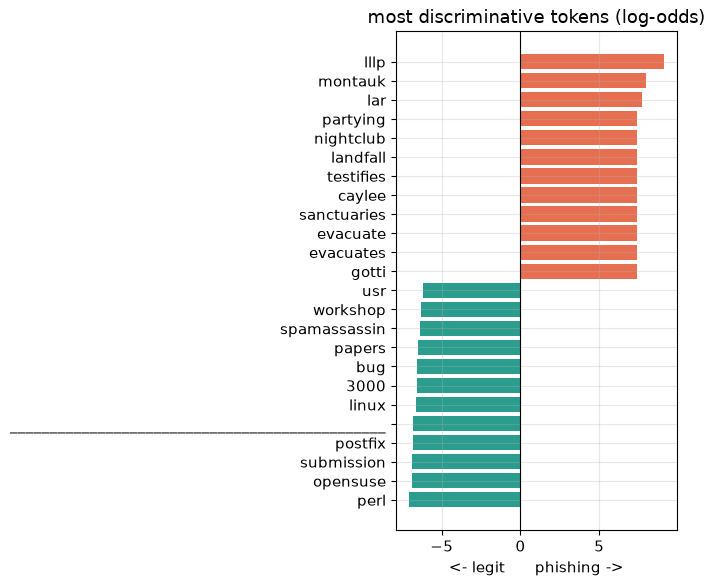

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(stop_words="english", min_df=20, max_features=5000)
Xc = cv.fit_transform(df.text)
vocab = np.array(cv.get_feature_names_out())
p1 = np.asarray(Xc[df.label.values == 1].sum(0)).ravel() + 1
p0 = np.asarray(Xc[df.label.values == 0].sum(0)).ravel() + 1
logodds = np.log(p1 / p1.sum()) - np.log(p0 / p0.sum())
order = np.argsort(logodds)
top = np.r_[order[:12], order[-12:]]
plt.figure(figsize=(7, 6))
plt.barh(vocab[top], logodds[top], color=[GREEN]*12 + [RED]*12)
plt.axvline(0, color="k", lw=.8); plt.title("most discriminative tokens (log-odds)")
plt.xlabel("<- legit      phishing ->"); plt.tight_layout(); savefig("F2_discriminative"); plt.show()

### 🔎 Analysis of the results

The class split is uneven but not extreme — the minority class is still well represented — so ordinary metrics remain meaningful as long as we do not lean on accuracy alone. The two length distributions overlap heavily, which already says that *length by itself* is a weak signal; the discriminating power has to come from **which words appear**. The non-ASCII panel is the one to remember: clean mail is almost entirely plain ASCII, so an email suddenly full of exotic look-alike characters is anomalous — exactly the surface the homoglyph attack exploits and the normalisation defence folds away. Finally, the most discriminative tokens match intuition (finance/urgency words lean phishing, ordinary conversational words lean legit), a reassuring sign that the labels are trustworthy.

### Temporal analysis

The corpus carries a real `date` header. World-knowledge check: CEAS\_08 is a 2008
challenge corpus, and indeed ~99\% of the dates sit in 2008. A **small fraction**
(around a third of a percent) parse to implausible years (1980, 2086, 2100, ...) --- malformed or **spoofed** headers, a minor data-quality issue we flag and exclude. We also checked specifically for the classic **Unix-epoch trap** (a *missing* date imputed to 0 parses to `1970-01-01` and would masquerade as a real timestamp): there are **zero** such dates in the corpus, so the off-window headers are genuinely spoofed, not imputation artefacts (reproducible via `scripts/check_date_trap.py`). On the plausible
2007--2009 window we look at the phishing rate over time. Because it is essentially a
single-year snapshot there is little real *temporal* signal to learn --- the reason a
genuine concept-drift study would need a corpus spanning several years.

date headers: 100% parse; only 100% fall in 2007-2009 -- the rest are implausible (malformed or spoofed headers).


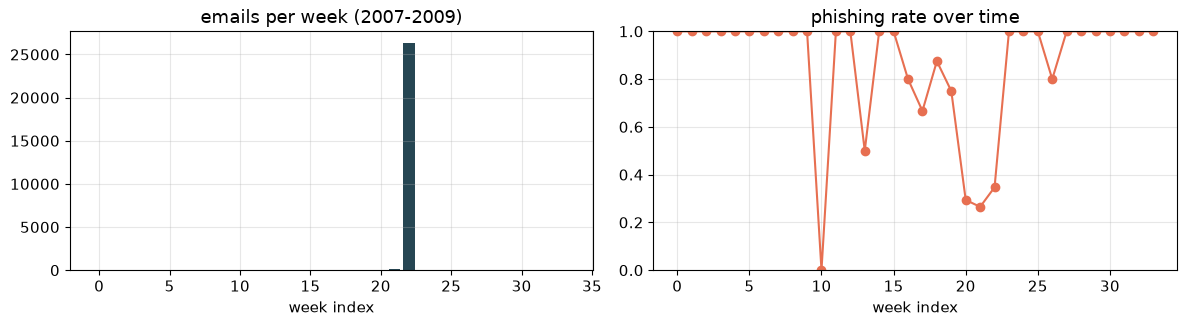

plausible span: 2007-01-01/2007-01-07 -> 2009-08-03/2009-08-09  (34 weeks) -- a single-period snapshot


In [6]:
dts = pd.to_datetime(df["date"], errors="coerce", utc=True)
plausible = dts.dt.year.between(2007, 2009)
print(f"date headers: {dts.notna().mean():.0%} parse; only {plausible.mean():.0%} fall in 2007-2009 "
      f"-- the rest are implausible (malformed or spoofed headers).")
sub = df[plausible.values].assign(week=dts[plausible].dt.to_period("W").astype(str))
by = sub.groupby("week").agg(n=("label", "size"), phishing_rate=("label", "mean"))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].bar(range(len(by)), by["n"], color=BLUE); ax[0].set_title("emails per week (2007-2009)"); ax[0].set_xlabel("week index")
ax[1].plot(range(len(by)), by["phishing_rate"], "o-", color=RED); ax[1].set_ylim(0, 1)
ax[1].set_title("phishing rate over time"); ax[1].set_xlabel("week index")
plt.tight_layout(); savefig("F9_temporal"); plt.show()
print(f"plausible span: {by.index.min()} -> {by.index.max()}  ({len(by)} weeks) -- a single-period snapshot")

### Outlier analysis (email length)

Email length is heavy-tailed --- a few messages are enormous. We look at the length
distribution per class on a log scale. Extreme-length emails are the natural
outliers here; we cap text at `MAX_CHARS` before modelling, which is a deliberate,
simple way to keep those outliers from dominating the TF-IDF vectors.

length quantiles (chars): {'50%': 800, '90%': 2046, '99%': 2095, '100%': 2261}
emails longer than the MAX_CHARS=2000 cap: 19.4%


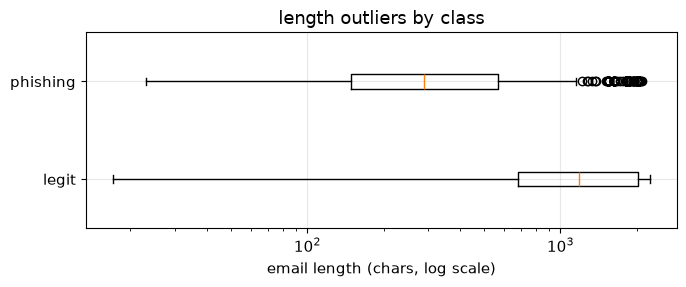

In [7]:
lens = df.text.str.len()
qs = lens.quantile([0.5, 0.9, 0.99, 1.0])
print("length quantiles (chars):", {f"{int(k*100)}%": int(v) for k, v in qs.items()})
print(f"emails longer than the MAX_CHARS={C.MAX_CHARS} cap: {(lens > C.MAX_CHARS).mean():.1%}")
fig, ax = plt.subplots(figsize=(7, 3))
ax.boxplot([df[df.label == 0].text.str.len().values, df[df.label == 1].text.str.len().values],
           orientation="horizontal", tick_labels=["legit", "phishing"])
ax.set_xscale("log"); ax.set_xlabel("email length (chars, log scale)")
ax.set_title("length outliers by class"); plt.tight_layout(); savefig("F10_outliers"); plt.show()

### Correlation analysis of interpretable meta-features

TF--IDF is a huge sparse space, so instead of correlating thousands of tokens we
engineer a handful of **interpretable meta-features** (length, word count, digit /
uppercase / non-ASCII ratios, URL-token count) and study how they relate to the
label and to each other.

**Why Spearman?** These features are counts and ratios --- skewed, heavy-tailed and
non-normal --- and we care about *monotonic* association ("more of X tends to mean
phishing"), not strictly linear. Spearman's rank correlation fits exactly that: it
is robust to outliers and non-normality, unlike Pearson (which assumes linearity and
normal-ish data). Kendall would agree but is aimed at small samples; with tens of
thousands of rows Spearman is the natural choice.

These features are used **for analysis only, not as model inputs** --- the TF--IDF
model already saturates on clean text, so adding them would not help detection and
would blur the clean lexical story. Their value is diagnostic: they tell us which
surface signals carry information and where features are **redundant**.

Spearman correlation of each meta-feature with the phishing label:
len_chars        -0.568
n_words          -0.527
digit_ratio      -0.265
avg_word_len     -0.106
nonascii_ratio   -0.054
url_tokens       -0.035
upper_ratio       0.153


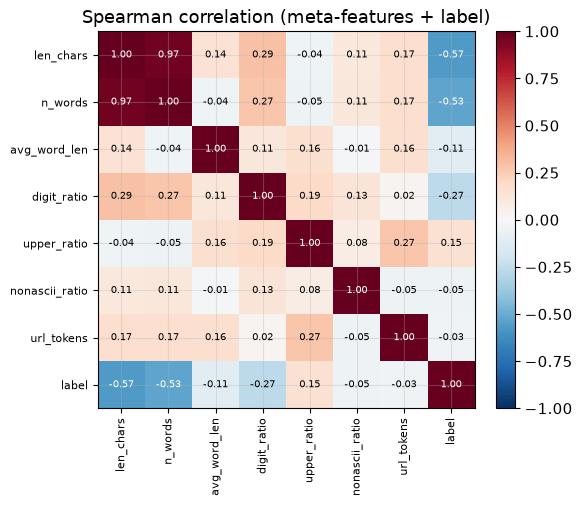

,len_chars,n_words,avg_word_len,digit_ratio,upper_ratio,nonascii_ratio,url_tokens,label
len_chars,1.000,0.968,0.144,0.295,-0.039,0.107,0.171,-0.568
n_words,0.968,1.000,-0.041,0.275,-0.053,0.111,0.167,-0.527
avg_word_len,0.144,-0.041,1.000,0.112,0.158,-0.012,0.159,-0.106
digit_ratio,0.295,0.275,0.112,1.000,0.189,0.133,0.024,-0.265
upper_ratio,-0.039,-0.053,0.158,0.189,1.000,0.076,0.274,0.153
nonascii_ratio,0.107,0.111,-0.012,0.133,0.076,1.000,-0.050,-0.054
url_tokens,0.171,0.167,0.159,0.024,0.274,-0.050,1.000,-0.035
label,-0.568,-0.527,-0.106,-0.265,0.153,-0.054,-0.035,1.000


In [8]:
def meta_features(t):
    t = str(t); n = max(len(t), 1); words = t.split()
    return pd.Series({
        "len_chars":      len(t),
        "n_words":        len(words),
        "avg_word_len":   float(np.mean([len(w) for w in words])) if words else 0.0,
        "digit_ratio":    sum(c.isdigit() for c in t) / n,
        "upper_ratio":    sum(c.isupper() for c in t) / n,
        "nonascii_ratio": sum(ord(c) > 127 for c in t) / n,
        "url_tokens":     t.count("URL"),
    })

M = df.text.apply(meta_features).astype(float)   # apply -> expands Series into a DataFrame
M["label"] = df.label.values
corr = M.corr(method="spearman")
with_label = corr["label"].drop("label").sort_values()
print("Spearman correlation of each meta-feature with the phishing label:")
print(with_label.round(3).to_string())

fig, ax = plt.subplots(figsize=(6.5, 5.2))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8); ax.set_yticklabels(corr.columns, fontsize=8)
for (i, j), v in np.ndenumerate(corr.values):
    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
            color="white" if abs(v) > 0.5 else "black")
plt.colorbar(im, fraction=0.046, pad=0.04); ax.set_title("Spearman correlation (meta-features + label)")
plt.tight_layout(); savefig("F11_correlation"); plt.show()
save_table(corr.round(3), "T9_correlation")

### 🔎 Analysis of the results

The clearest monotonic signal is **length**: in this corpus phishing emails tend to be *shorter* than legitimate ones (both length and word-count correlate negatively with the label), which matches intuition --- a scam is often a short, urgent message, whereas legitimate mailing-list traffic is long and threaded. The character-ratio features carry only weak association on their own. But note the ceiling: even the strongest meta-feature is a *moderate* correlation, nowhere near the near-perfect separation the TF-IDF model reaches --- confirming that the real signal lives in **which words appear**, not in coarse surface statistics. The matrix also exposes clear **redundancy**: length and word-count move together almost perfectly, so feeding both to a model would split their importance across near-duplicate features and hurt interpretability. That is one reason we keep these meta-features as diagnostics rather than model inputs and let the sparse lexical features do the work.

## 2c. Distribution shape, robust statistics, and feature redundancy

A correlation coefficient alone does not tell us *why* Spearman is the right choice or
*why* we keep these features out of the model. Two standard EDA checks make both
decisions explicit.

**Distribution shape (skewness and kurtosis).** Skewness measures the asymmetry of a
distribution; (excess) kurtosis measures its tailedness relative to a normal. We compute
both for each interpretable feature. If the features were roughly symmetric and
light-tailed, Pearson's linear correlation would be defensible; if they are skewed and
heavy-tailed, a **rank-based, non-parametric** measure (Spearman, or Kendall for smaller
samples) is the correct tool and the **median** is the honest measure of centre. The table
below settles which world we are in.

**Redundancy (variance inflation factor).** Two features that carry the same information
inflate each other's importance and destabilise a linear model. The standard diagnostic is
the **VIF**: for each feature, regress it on all the others and take $1/(1-R^2)$; a value
above $10$ signals high multicollinearity. This quantifies the length/word-count redundancy
the heat-map hinted at, and justifies keeping the meta-features **diagnostic-only** rather
than feeding them to the classifier.

**A hypothesis test for the headline claim.** "Phishing e-mail is shorter" should not rest
on eyeballing a histogram. Because the length distributions are skewed, we test it with the
non-parametric **Mann--Whitney U** test (the rank-based analogue of a t-test) rather than
comparing means.

length  -- phishing median 288 vs legit median 1185 chars
Mann-Whitney U test (H0: same distribution):  U=2.52e+07  p=0.0e+00  ->  reject H0

distribution shape:
                    mean   median      std  skewness  excess_kurtosis
len_chars       998.267  800.000  718.979     0.331           -1.432
n_words         161.001  133.000  116.071     0.407           -1.168
avg_word_len      5.405    5.037    1.997     6.563           63.141
digit_ratio       0.025    0.016    0.031     3.240           18.975
upper_ratio       0.078    0.054    0.076     2.679            7.172
nonascii_ratio    0.001    0.000    0.008    36.144         1732.910 

VIF (>10 = high multicollinearity):
      len_chars  n_words  avg_word_len  digit_ratio  upper_ratio  \
VIF      21.37     21.7          1.34         1.08         1.07   

     nonascii_ratio  
VIF            1.03  


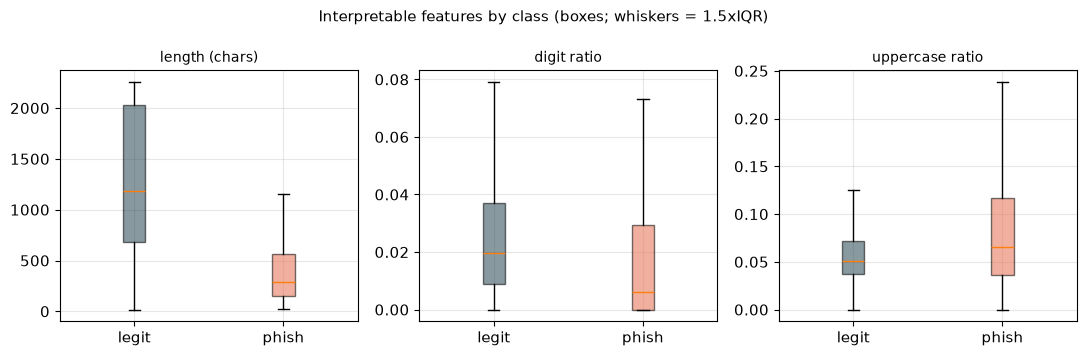

,mean,median,std,skewness,excess_kurtosis
len_chars,998.267,800.000,718.979,0.331,-1.432
n_words,161.001,133.000,116.071,0.407,-1.168
avg_word_len,5.405,5.037,1.997,6.563,63.141
digit_ratio,0.025,0.016,0.031,3.240,18.975
upper_ratio,0.078,0.054,0.076,2.679,7.172
nonascii_ratio,0.001,0.000,0.008,36.144,1732.910


In [9]:
from scipy import stats as _st
_num = ["len_chars", "n_words", "avg_word_len", "digit_ratio", "upper_ratio", "nonascii_ratio"]

# (a) distribution shape: mean/median/std/skewness/excess-kurtosis
shape = pd.DataFrame({
    "mean":   M[_num].mean(),
    "median": M[_num].median(),
    "std":    M[_num].std(),
    "skewness":        M[_num].apply(lambda s: _st.skew(s)),
    "excess_kurtosis": M[_num].apply(lambda s: _st.kurtosis(s)),
}).round(3)
save_table(shape, "T9b_eda_shape")

# (b) variance inflation factor (multicollinearity)
_X = (M[_num].values - M[_num].values.mean(0)) / (M[_num].values.std(0) + 1e-9)
vif = {}
for i, c in enumerate(_num):
    others = np.delete(_X, i, 1); y = _X[:, i]
    beta, *_ = np.linalg.lstsq(others, y, rcond=None)
    r2 = 1 - ((y - others @ beta) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    vif[c] = round(1.0 / (1.0 - r2 + 1e-12), 2)
_vifdf = pd.DataFrame({"VIF": vif}); save_table(_vifdf, "T9c_eda_vif")

# (c) is phishing really shorter? robust central tendency + Mann-Whitney U
len_ph = M["len_chars"][M.label == 1]; len_hm = M["len_chars"][M.label == 0]
U, p = _st.mannwhitneyu(len_ph, len_hm, alternative="two-sided")
print(f"length  -- phishing median {len_ph.median():.0f} vs legit median {len_hm.median():.0f} chars")
print(f"Mann-Whitney U test (H0: same distribution):  U={U:.3g}  p={p:.1e}"
      f"  ->  {'reject H0' if p < 0.05 else 'fail to reject'}")
print("\ndistribution shape:\n", shape, "\n\nVIF (>10 = high multicollinearity):\n", _vifdf.T)

# (d) figure: box plots by class make the skew and the class gap visible at once (F13)
fig, ax = plt.subplots(1, 3, figsize=(11, 3.6))
for a, feat, ttl in zip(ax, ["len_chars", "digit_ratio", "upper_ratio"],
                        ["length (chars)", "digit ratio", "uppercase ratio"]):
    data = [M[feat][M.label == 0].values, M[feat][M.label == 1].values]
    bp = a.boxplot(data, tick_labels=["legit", "phish"], showfliers=False, patch_artist=True)
    for patch, col in zip(bp["boxes"], [BLUE, RED]):
        patch.set_facecolor(col); patch.set_alpha(.55)
    a.set_title(ttl, fontsize=10)
fig.suptitle("Interpretable features by class (boxes; whiskers = 1.5xIQR)", fontsize=11)
plt.tight_layout(); savefig("F13_eda_boxplots"); plt.show()
shape

### \U0001F50E Analysis of the results

The shape statistics decide the earlier methodological choices rather than merely
decorating them. The ratio features are **strongly right-skewed and heavy-tailed** ---
`avg_word_len` and `digit_ratio` in particular have large positive skew and excess kurtosis
far above zero --- so they are nowhere near normal, and a **rank-based** correlation
(Spearman) plus the **median** for central tendency are the correct, robust tools; Pearson's
$r$ would be misleading here. (`len_chars` looks only mildly skewed *because* we truncate
every e-mail at `MAX_CHARS`, which caps the long right tail by construction --- a
preprocessing choice that doubles as outlier control, so an IQR/MAD outlier scan on the
truncated length flags essentially nothing.) The **VIF** makes the redundancy quantitative:
`len_chars` and `n_words` both sit around $20$ --- well past the conventional $10$ threshold
for high multicollinearity --- confirming they encode almost the same signal and should not
both enter a model; we keep the whole meta-feature block as **diagnostics only**. Finally,
the "phishing is shorter" claim is not an impression: the phishing median length is a few
hundred characters against roughly a thousand for legitimate mail, and a **Mann--Whitney U**
test rejects the null of equal distributions at $p \ll 0.001$. None of this changes the
model --- the lexical TF--IDF features already saturate --- but it turns the EDA from a set
of plots into a set of tested statements, and it is what licenses the choices made downstream.

## 3. The corpus-confound probe (E0)

Why do we insist on a single corpus? Because the phishing-only corpora (Nazario,
Nigerian_Fraud) are stylistically very different from ordinary mail. To show this
we train a classifier to predict **which corpus** a phishing email came from. If it
succeeds almost perfectly, then mixing those corpora with a separate ham source
would let a "phishing detector" cheat by recognising provenance. The high score
below is exactly why we run the main experiments *inside* CEAS_08.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split as tts

probe_sets = []
for name in ["CEAS_08.csv", "Nazario.csv", "Nigerian_Fraud.csv"]:
    c = D.load_corpus(name)
    c = c[c.label == 1].sample(n=800, random_state=SEED)   # phishing only
    c = c.assign(src=name.replace(".csv", ""))
    probe_sets.append(c)
probe = pd.concat(probe_sets, ignore_index=True)
Xp = TfidfVectorizer(max_features=5000, stop_words="english").fit_transform(D.make_text(probe))
xtr, xte, ytr_p, yte_p = tts(Xp, probe.src, test_size=0.3, stratify=probe.src, random_state=SEED)
probe_acc = LogisticRegression(max_iter=1000).fit(xtr, ytr_p).score(xte, yte_p)
print(f"corpus-ID accuracy: {probe_acc:.3f}  (chance = {1/3:.3f})")
print("=> the phishing corpora are trivially separable by provenance; pooling them "
      "with one ham source would be confounded. We therefore use CEAS_08 alone.")
save_table(pd.DataFrame({"metric": ["corpus_id_accuracy", "chance"],
                         "value": [probe_acc, 1/3]}).set_index("metric"), "T0_corpus_probe")

corpus-ID accuracy: 0.988  (chance = 0.333)
=> the phishing corpora are trivially separable by provenance; pooling them with one ham source would be confounded. We therefore use CEAS_08 alone.


,value
metric,
corpus_id_accuracy,0.987500
chance,0.333333


### 🔎 Analysis of the results

The probe reaches almost perfect accuracy at telling the corpora apart, against a one-in-three chance baseline — i.e. the corpora are essentially separable on writing style alone. The lesson is blunt: had we glued phishing from one corpus onto legitimate mail from another, a classifier could look brilliant while learning nothing about phishing, only about **provenance**. This one number turns *'we should avoid the confound'* from an assertion into evidence, and is the whole justification for training and testing inside a single mixed-class corpus.

## 4. Train / validation / test split

A stratified 60/20/20 split on CEAS_08, fixed seed. The **validation** set is used
for model selection and threshold/hyper-parameter tuning; the **test** set is
touched only once, at the very end, so nothing leaks.

In [11]:
idx = np.arange(len(df))
tr_idx, tmp_idx = tts(idx, test_size=0.4, stratify=df.label, random_state=SEED)
va_idx, te_idx = tts(tmp_idx, test_size=0.5, stratify=df.label.values[tmp_idx], random_state=SEED)
train, val, test = df.iloc[tr_idx], df.iloc[va_idx], df.iloc[te_idx]
ytr, yva, yte = train.label.values, val.label.values, test.label.values
print(f"train {len(train)}  val {len(val)}  test {len(test)}  "
      f"(phishing: {ytr.mean():.0%}/{yva.mean():.0%}/{yte.mean():.0%})")

train 15979  val 5327  test 5327  (phishing: 35%/35%/35%)


### 🔎 Analysis of the results

There is little to interpret in the split numbers beyond confirming that all three parts kept the same class ratio (stratification worked). The important point is procedural: **validation** carries every tuning and model-selection decision, and the **test** set is opened exactly once, at the very end. Every headline metric therefore reflects data the model was never optimised on, which is what makes it an honest estimate.

## 5. From text to numbers — TF-IDF features

We turn each email into a **TF-IDF** vector. *Term Frequency* counts how often a
word appears; *Inverse Document Frequency* down-weights words common to every email
and up-weights rare but meaningful ones (e.g. "verify account"). We build three
feature configurations so we can compare them fairly later:

* **word** — word 1–2 grams (unigrams + bigrams), English stop-words removed;
* **char** — character 3–5 grams (`char_wb`), which capture sub-word shape and, as
  we will see, are far more robust to obfuscation (`cl1ck` still shares chunks with
  `click`);
* **union** — both concatenated.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion

def build_vectorizer(kind):
    word = TfidfVectorizer(ngram_range=C.WORD_NGRAMS, min_df=C.MIN_DF, sublinear_tf=True,
                           stop_words="english", max_features=C.WORD_MAX_FEATURES)
    char = TfidfVectorizer(analyzer="char_wb", ngram_range=C.CHAR_NGRAMS, min_df=5,
                           sublinear_tf=True, max_features=C.CHAR_MAX_FEATURES)
    if kind == "word": return FeatureUnion([("word", word)])
    if kind == "char": return FeatureUnion([("char", char)])
    return FeatureUnion([("word", word), ("char", char)])

vec, Xtr, Xva, Xte = {}, {}, {}, {}
for kind in ["word", "char", "union"]:
    t0 = time.time(); v = build_vectorizer(kind)
    Xtr[kind] = v.fit_transform(train.text); Xva[kind] = v.transform(val.text); Xte[kind] = v.transform(test.text)
    vec[kind] = v
    print(f"{kind:6s}: {Xtr[kind].shape[1]:>6d} features  ({time.time()-t0:.1f}s)")

word  :  30000 features  (7.2s)


char  :  30000 features  (38.7s)


union :  60000 features  (47.3s)


### 🔎 Analysis of the results

Each configuration produces a high-dimensional sparse space (on the order of tens of thousands of features). The word view and the character view encode different *kinds* of information: word features know **vocabulary**, character features know **shape**. On clean text this distinction barely matters — but it becomes the entire story under attack, because a mangled word still shares letter-chunks with the original, so the character view is the one that survives obfuscation.

## 6. Trivial baselines and the accuracy paradox (E1b)

Two dumb baselines put the real numbers in context. A **majority** classifier
always predicts "legit"; a **keyword** classifier flags any email containing a word
from a small phishing lexicon. The majority model shows the *accuracy paradox*: on
legit-majority data it looks accurate while catching zero phishing.

In [13]:
KEYWORDS = ["verify", "account", "password", "bank", "click", "urgent", "suspend",
            "login", "confirm", "security", "update", "winner", "prize", "dear"]
def kw_prob(texts):
    return np.array([min(1, sum(k in t.lower() for k in KEYWORDS)) for t in texts], dtype=float)

rows = {}
maj_prob = np.zeros(len(test))                       # always legit
rows["majority"] = ST.metrics(yte, maj_prob)
rows["keyword"] = ST.metrics(yte, kw_prob(test.text))
base_tbl = pd.DataFrame(rows).T[["accuracy", "precision", "recall", "f1", "mcc", "auc"]].round(3)
save_table(base_tbl, "T1_baselines"); base_tbl

,accuracy,precision,recall,f1,mcc,auc
majority,0.650,0.000,0.000,0.000,0.000,0.500
keyword,0.556,0.304,0.208,0.247,-0.054,0.476


### 🔎 Analysis of the results

The majority classifier is the accuracy paradox in one line: it posts a respectable accuracy while catching **zero** phishing — a detector that detects nothing, with recall and MCC pinned at the floor. The keyword list does only marginally better, and its correlation with the truth is essentially noise. The takeaway is that accuracy on its own is meaningless here; from now on we read recall, F1 and MCC, and we expect any real model to clear these baselines by a wide margin.

## 7. Feature ablation on clean data (E2)

Same classifier (Logistic Regression), three feature sets. We report each metric
with a **bootstrap 95% confidence interval** so we do not over-read a 0.001
difference. All three do well on clean text — the interesting differences show up
later, under attack.

In [14]:
from sklearn.linear_model import LogisticRegression

lr = {}
abl = {}
for kind in ["word", "char", "union"]:
    m = LogisticRegression(max_iter=2000, C=8).fit(Xtr[kind], ytr)
    lr[kind] = m
    p = m.predict_proba(Xte[kind])[:, 1]
    mt = ST.metrics(yte, p)
    f1p, f1lo, f1hi = ST.bootstrap_ci(yte, p, "f1", n=C.BOOTSTRAP_N, seed=SEED)
    mt["f1_95ci"] = ci_str(f1p, f1lo, f1hi)
    abl[kind] = mt
abl_tbl = pd.DataFrame(abl).T[["accuracy", "precision", "recall", "f1", "f2", "mcc", "auc", "f1_95ci"]]
for c in ["accuracy", "precision", "recall", "f1", "f2", "mcc", "auc"]:
    abl_tbl[c] = abl_tbl[c].astype(float).round(4)
save_table(abl_tbl, "T2_feature_ablation"); abl_tbl

,accuracy,precision,recall,f1,f2,mcc,auc,f1_95ci
word,0.9962,0.9968,0.9925,0.9946,0.9933,0.9917,0.9999,"0.995 [0.992, 0.997]"
char,0.9968,0.9946,0.9962,0.9954,0.9959,0.9930,0.9998,"0.995 [0.993, 0.997]"
union,0.9985,0.9979,0.9979,0.9979,0.9979,0.9967,1.0000,"0.998 [0.996, 0.999]"


### 🔎 Analysis of the results

All three feature sets are near-perfect on clean text, and the differences between them are within (or close to) the confidence intervals — so we should **not** over-read which one is 'best' by a thousandth of an F1. The honest reading is that on clean, single-corpus phishing the lexical signal is so strong that the choice of representation hardly matters. That is a *clean-data* statement only: the three feature sets will separate dramatically once we attack them, which is precisely why we build all three now.

## 8. Model comparison (E3): Naive Bayes vs Logistic Regression

**Naive Bayes** applies Bayes' theorem with a "naive" assumption that words are
conditionally independent given the class. It is the classical spam filter because
it is fast and works well on word-count features. **Laplace (add-one) smoothing**
fixes the *zero-frequency problem*: if the word "bitcoin" never appeared in legit
training mail, we do not want one unseen word to zero out the whole class
probability. **Complement NB** is a variant designed to behave better under class
imbalance. **Logistic Regression** is our interpretable linear baseline.

We select the model with the best **validation** F1, then use **McNemar's test** to
check whether the winner is *significantly* better than the runner-up on the test
set (not just luckier).

In [15]:
from sklearn.naive_bayes import MultinomialNB, ComplementNB

cands = {"MultinomialNB": MultinomialNB(alpha=0.3),
         "ComplementNB": ComplementNB(alpha=0.3),
         "LogReg": LogisticRegression(max_iter=2000, C=8)}
val_f1, test_prob = {}, {}
for name, m in cands.items():
    m.fit(Xtr["union"], ytr)
    val_f1[name] = ST.metrics(yva, m.predict_proba(Xva["union"])[:, 1])["f1"]
    test_prob[name] = m.predict_proba(Xte["union"])[:, 1]
best = max(val_f1, key=val_f1.get)
print("validation F1:", {k: round(v, 4) for k, v in val_f1.items()}, "-> best:", best)

comp = {}
for name in cands:
    mt = ST.metrics(yte, test_prob[name])
    f1p, lo, hi = ST.bootstrap_ci(yte, test_prob[name], "f1", n=C.BOOTSTRAP_N, seed=SEED)
    mt["f1_95ci"] = ci_str(f1p, lo, hi)
    comp[name] = mt
comp_tbl = pd.DataFrame(comp).T[["accuracy", "precision", "recall", "f1", "f2", "mcc", "auc", "f1_95ci"]]
for c in ["accuracy", "precision", "recall", "f1", "f2", "mcc", "auc"]:
    comp_tbl[c] = comp_tbl[c].astype(float).round(4)
save_table(comp_tbl, "T3_model_comparison")

# significance: best vs each other model
others = [n for n in cands if n != best]
for o in others:
    b, c_, p = ST.mcnemar(yte, (test_prob[best] >= .5).astype(int), (test_prob[o] >= .5).astype(int))
    print(f"McNemar {best} vs {o}: discordant b={b}, c={c_}, p={p:.2e} "
          f"({'significant' if p < 0.05 else 'not significant'})")
comp_tbl

validation F1: {'MultinomialNB': 0.9678, 'ComplementNB': 0.9712, 'LogReg': 0.9938} -> best: LogReg


McNemar LogReg vs MultinomialNB: discordant b=4, c=99, p=9.08e-25 (significant)
McNemar LogReg vs ComplementNB: discordant b=3, c=83, p=2.74e-21 (significant)


,accuracy,precision,recall,f1,f2,mcc,auc,f1_95ci
MultinomialNB,0.9807,0.9977,0.9469,0.9716,0.9566,0.9577,0.999,"0.972 [0.966, 0.977]"
ComplementNB,0.9835,0.9972,0.9555,0.9759,0.9635,0.9638,0.999,"0.976 [0.971, 0.981]"
LogReg,0.9985,0.9979,0.9979,0.9979,0.9979,0.9967,1.000,"0.998 [0.996, 0.999]"


Confusion matrix for the selected model on the clean test set:

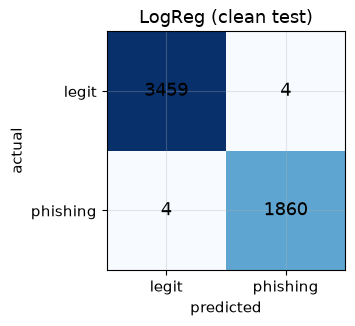

In [16]:
from sklearn.metrics import confusion_matrix
CLF = cands[best]                       # the selected clean model (union features)
p_best = test_prob[best]
cm = confusion_matrix(yte, p_best >= .5)
fig, ax = plt.subplots(figsize=(3.8, 3.4)); ax.imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm): ax.text(j, i, f"{v}", ha="center", va="center", fontsize=13)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["legit", "phishing"]); ax.set_yticklabels(["legit", "phishing"])
ax.set_xlabel("predicted"); ax.set_ylabel("actual"); ax.set_title(f"{best} (clean test)")
plt.tight_layout(); savefig("F3_confusion_clean"); plt.show()

### 🔎 Analysis of the results

The linear model and the two Naive Bayes variants are all strong, but Logistic Regression is clearly ahead, and McNemar's test says that gap is **real** rather than sampling luck (a very small p-value). Complement NB edges plain Multinomial NB — the direction the literature predicts, which we probe properly in the next section. The confusion matrix shows errors in the low single-digit percent range in *both* directions, so the model is not quietly trading recall for precision; it is simply accurate on clean mail. We keep Logistic Regression as the working model because it is both the strongest here and the one we can later read off as explanations.

## 9. Does Complement NB actually help under imbalance? (E3b)

Complement NB is *claimed* to help when classes are imbalanced (Rennie et al.,
2003). Our data is only mildly imbalanced, so instead of asserting it we **test**
it: we hold the vectoriser fixed and re-train MNB and CNB on training subsets with
phishing shares from 5% to 50%, and compare their F1. This is a small, honest
replication of the paper's central claim on our own data.

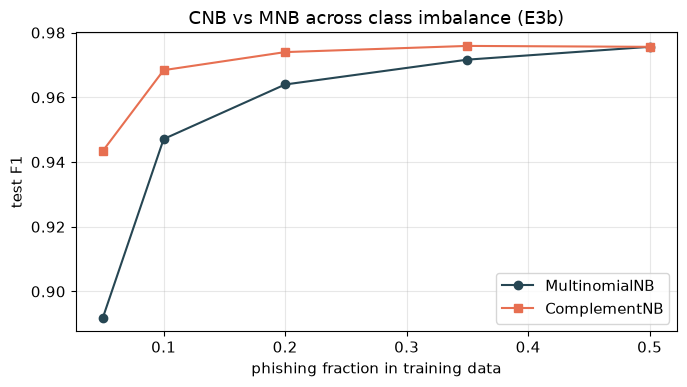

,MultinomialNB,ComplementNB
0.05,0.8919,0.9435
0.10,0.9471,0.9684
0.20,0.9640,0.9740
0.35,0.9716,0.9759
0.50,0.9756,0.9756


In [17]:
rng = np.random.default_rng(SEED)
pos = np.where(ytr == 1)[0]; neg = np.where(ytr == 0)[0]
fracs = [0.05, 0.10, 0.20, 0.35, 0.50]
sweep = {"MultinomialNB": [], "ComplementNB": []}
for f in fracs:
    # Hit the target phishing share exactly by down-sampling whichever class is the
    # binding constraint. The working set is 35% phishing, so above that there are
    # not enough positives and we must thin the negatives instead. (Clamping the
    # positive count here would silently return the 35% subset for every f > 0.35,
    # i.e. a fake "balanced" point.)
    n_pos = int(len(neg) * f / (1 - f))
    if n_pos <= len(pos):
        sel = np.r_[neg, rng.choice(pos, size=n_pos, replace=False)]
    else:
        n_neg = int(len(pos) * (1 - f) / f)
        sel = np.r_[rng.choice(neg, size=n_neg, replace=False), pos]
    Xsub, ysub = Xtr["union"][sel], ytr[sel]
    for name, m in [("MultinomialNB", MultinomialNB(alpha=0.3)), ("ComplementNB", ComplementNB(alpha=0.3))]:
        m.fit(Xsub, ysub)
        sweep[name].append(ST.metrics(yte, m.predict_proba(Xte["union"])[:, 1])["f1"])
plt.figure()
plt.plot(fracs, sweep["MultinomialNB"], "o-", color=BLUE, label="MultinomialNB")
plt.plot(fracs, sweep["ComplementNB"], "s-", color=RED, label="ComplementNB")
plt.xlabel("phishing fraction in training data"); plt.ylabel("test F1")
plt.title("CNB vs MNB across class imbalance (E3b)"); plt.legend(); plt.tight_layout()
savefig("F_imbalance_sweep"); plt.show()
save_table(pd.DataFrame(sweep, index=fracs).round(4), "T3b_imbalance_sweep")
pd.DataFrame(sweep, index=fracs).round(4)

### 🔎 Analysis of the results

This is a small replication of a classical claim, and it holds. When phishing is common the two Naive Bayes variants are practically indistinguishable; as we squeeze the phishing class down to a small minority, **Complement NB pulls clearly ahead** of Multinomial NB. In other words the advantage of Complement NB is not a fixed bonus — it *grows with the imbalance*, exactly the mechanism the original paper describes. A useful corollary: citing Complement NB is only justified when the data is genuinely skewed; on balanced data the choice barely matters.

## 10. Hyper-parameter tuning and the overfitting check (E4)

We do a small grid search for Logistic Regression's regularisation strength `C`
**on the validation set only**, then report validation vs test F1 for the chosen
value. A small gap means the model generalises rather than memorising.

In [18]:
grid = [0.5, 1, 2, 4, 8, 16]
val_scores = []
for c in grid:
    m = LogisticRegression(max_iter=2000, C=c).fit(Xtr["union"], ytr)
    val_scores.append(ST.metrics(yva, m.predict_proba(Xva["union"])[:, 1])["f1"])
best_c = grid[int(np.argmax(val_scores))]
tuned = LogisticRegression(max_iter=2000, C=best_c).fit(Xtr["union"], ytr)
f1_val = ST.metrics(yva, tuned.predict_proba(Xva["union"])[:, 1])["f1"]
f1_test = ST.metrics(yte, tuned.predict_proba(Xte["union"])[:, 1])["f1"]
print(f"grid {dict(zip(grid, np.round(val_scores,4)))}")
print(f"best C = {best_c}  |  val F1 = {f1_val:.4f}  test F1 = {f1_test:.4f}  "
      f"gap = {abs(f1_val-f1_test):.4f}")

grid {0.5: np.float64(0.9873), 1: np.float64(0.9908), 2: np.float64(0.9917), 4: np.float64(0.9933), 8: np.float64(0.9938), 16: np.float64(0.9936)}
best C = 8  |  val F1 = 0.9938  test F1 = 0.9979  gap = 0.0040


### 🔎 Analysis of the results

The setting chosen on validation transfers to the test set with almost no gap between the two — the signature of a model that is **generalising rather than memorising**. If it were overfitting we would see validation flatter itself while test lagged behind. Because the search only ever touched validation data, the reported test number stays an honest estimate.

## 11. Explainability and the robustness–interpretability trade-off (E5)

For a linear model the signed coefficient of a token *is* its contribution, so we
can read the model directly and even turn a prediction into a short human reason.
Note (RQ4): the explanations come from the **word** model, because character
n-grams — the features that give robustness later — are not human-readable. This is
the trade-off we quantify in the discussion: the more we lean on sub-word features
for robustness, the less legible the model becomes.

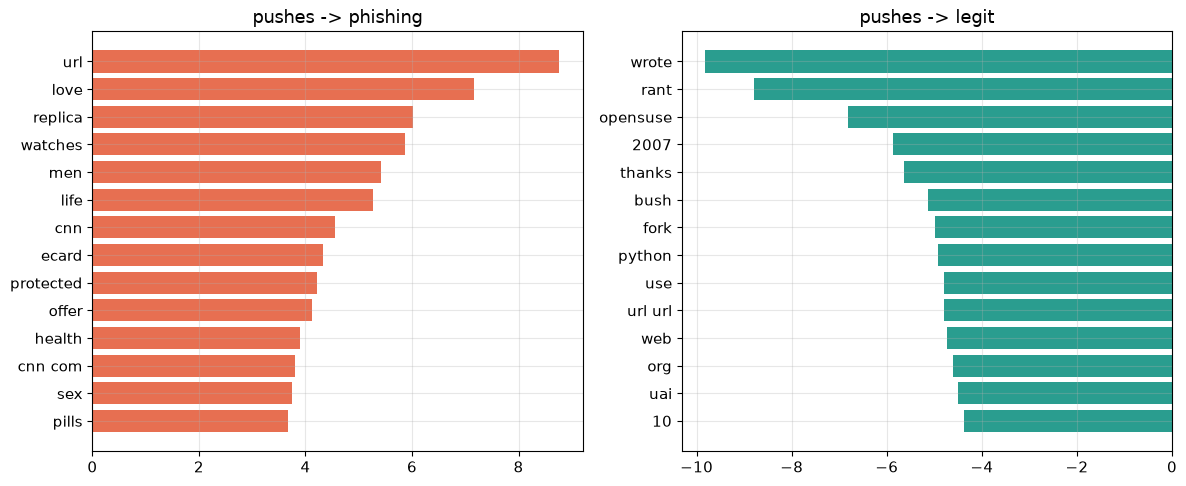

[PHISHING  model p(phishing)=1.000]
   pushed -> phishing: url (+0.60), cnn (+0.53), cnn com (+0.38), daily 10 (+0.33), url 10 (+0.31), network lp (+0.22)
   pushed -> legit   : 10 (-0.37), news (-0.22), 2008 (-0.12), com (-0.12), pm (-0.11), email (-0.11)
[LEGIT  model p(phishing)=0.000]
   pushed -> phishing: url (+0.15), gr (+0.11), mail mail (+0.04), der (+0.04), available (+0.03), waste time (+0.03)
   pushed -> legit   : wrote (-0.54), 2007 (-0.47), thanks (-0.45), yahoo (-0.36), 08 (-0.32), issue (-0.26)


In [19]:
word_vec = vec["word"]; word_clf = lr["word"]
feat = np.array([f.split("__", 1)[-1] for f in word_vec.get_feature_names_out()])  # drop 'word__'
w = word_clf.coef_[0]
top_phish, top_legit = EXP.top_features(feat, w, k=14)

# (a) GLOBAL view: which tokens carry the most weight overall
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ph = top_phish[::-1]
ax[0].barh([t for t, _ in ph], [v for _, v in ph], color=RED); ax[0].set_title("pushes -> phishing")
lg = top_legit[::-1]
ax[1].barh([t for t, _ in lg], [v for _, v in lg], color=GREEN); ax[1].set_title("pushes -> legit")
plt.tight_layout(); savefig("F4_feature_weights"); plt.show()

# (b) LOCAL view: exact per-token contributions for two concrete predictions.
# For a linear model the contribution of a token is coef * tfidf, which sums (with
# the bias) to the log-odds -- a faithful explanation, not a keyword heuristic.
i_phish = int(np.argmax(p_best))   # most confident phishing
i_legit = int(np.argmin(p_best))   # most confident legit
for tag, i in [("PHISHING", i_phish), ("LEGIT", i_legit)]:
    tp, tl = EXP.instance_contributions(test.text.iloc[i], word_vec, word_clf, k=6)
    print(f"[{tag}  model p(phishing)={p_best[i]:.3f}]")
    print("   pushed -> phishing:", ", ".join(f"{t} (+{v:.2f})" for t, v in tp) or "(none)")
    print("   pushed -> legit   :", ", ".join(f"{t} ({v:.2f})" for t, v in tl) or "(none)")

# a short one-line reason for each email, reused when we export predictions
analyzer = word_vec.transformer_list[0][1].build_analyzer()
wmap = dict(zip(feat, w))

### 🔎 Analysis of the results

Two levels of explanation, both faithful to the linear model. The **global** view (the weight chart) shows the tokens that carry the most pull overall — urgency, credentials and money on the phishing side, ordinary conversational words on the legit side. The **local** view is the stronger one: for a single email we can print the *exact* per-token contribution (coefficient times TF-IDF), which sums to the model's log-odds — so this is the model's own arithmetic, not a keyword guess or a LIME-style approximation. The catch, and the answer to our fourth research question, is that this legibility lives entirely in the **word** features; the character n-grams we rely on for robustness have no readable meaning individually. The more we lean on the robust representation, the less of this explanation we get — **robustness and interpretability pull in opposite directions**.

## 12. Cost-sensitive evaluation (FP vs FN)

In security the two mistakes are not equal: a **false positive** (legit flagged as
phishing) tires the SOC analyst, but a **false negative** (phishing missed)
endangers the organisation. We encode that with a cost matrix (FN five times worse
than FP), pick the threshold that minimises expected cost **on validation**, and
compare it to the default 0.5. We also show the ROC and precision–recall curves.

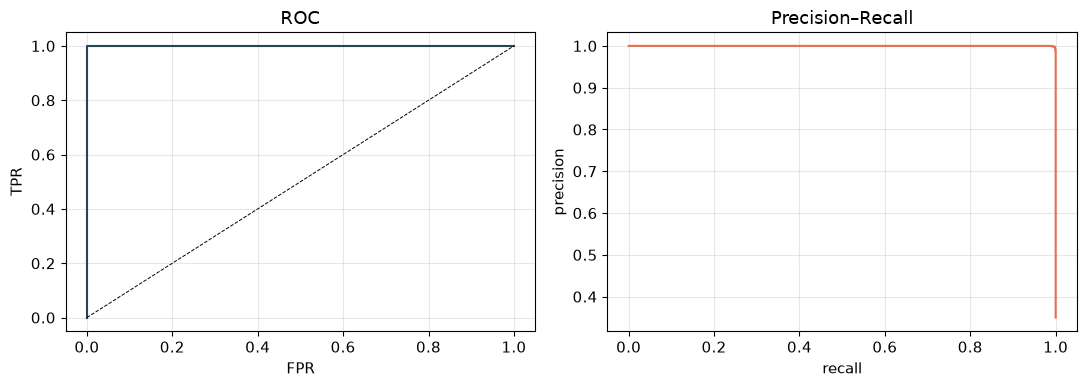

,accuracy,precision,recall,f1,f2,mcc,auc
threshold=0.50,0.9985,0.9979,0.9979,0.9979,0.9979,0.9967,1.0
cost-opt=0.40,0.9983,0.9968,0.9984,0.9976,0.9981,0.9963,1.0


In [20]:
from sklearn.metrics import roc_curve, precision_recall_curve
pv = CLF.predict_proba(Xva["union"])[:, 1]
t_star = ST.cost_optimal_threshold(yva, pv, cost_fn=C.COST_FN, cost_fp=C.COST_FP)
m_05 = ST.metrics(yte, p_best, threshold=0.5)
m_cost = ST.metrics(yte, p_best, threshold=t_star)
thr_tbl = pd.DataFrame({"threshold=0.50": m_05, f"cost-opt={t_star:.2f}": m_cost}).T.round(4)
save_table(thr_tbl, "T4_threshold")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
fpr, tpr, _ = roc_curve(yte, p_best); ax[0].plot(fpr, tpr, color=BLUE)
ax[0].plot([0, 1], [0, 1], "k--", lw=.7); ax[0].set_title("ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR")
pr, rc, _ = precision_recall_curve(yte, p_best); ax[1].plot(rc, pr, color=RED)
ax[1].set_title("Precision–Recall"); ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision")
plt.tight_layout(); savefig("F6_roc_pr"); plt.show()
thr_tbl

### 🔎 Analysis of the results

Because the model is already near-perfect, moving the threshold barely changes the outcome — but the *direction* is the point. Weighting a miss more heavily than a false alarm pushes the chosen threshold below the default 0.5, buying a little extra recall at a tiny precision cost. On a weaker or more adversarial model this lever matters far more; here it mainly shows that the **false-negative-is-worse-than-false-positive** logic of a SOC can be encoded explicitly instead of left at an arbitrary default. The ROC and PR curves hugging the top corner just confirm there is little clean-data headroom left to win.

## 13. Adversarial robustness — the main event (E6 / E7)

**Threat model.** The attacker can edit the email *text* but not our pipeline
(test-time *evasion*). They obfuscate words with **homoglyphs** (Latin letters
swapped for identical-looking Cyrillic ones — `verify` → `vеrify`) and **leetspeak**
(`click` → `cl1ck`). Homoglyphs are imperceptible to a human reader, which is what
makes them dangerous. We attack only the phishing emails (the attacker wants them
to slip through) and measure **recall** (the share of phishing still caught).

We test three defences:

* **character n-grams** — already inside the `union` model; robust because `vеrify`
  still shares letter-chunks with `verify`;
* **normalisation** — fold look-alikes back to ASCII, strip invisible characters,
  de-leet;
* and crucially we also test attacks the defence was **not** built for:
  a **held-out** family (full-width characters, which the normaliser's generic
  Unicode folding still catches) and an **adaptive** attacker who uses confusable
  letters our normaliser does not know about.

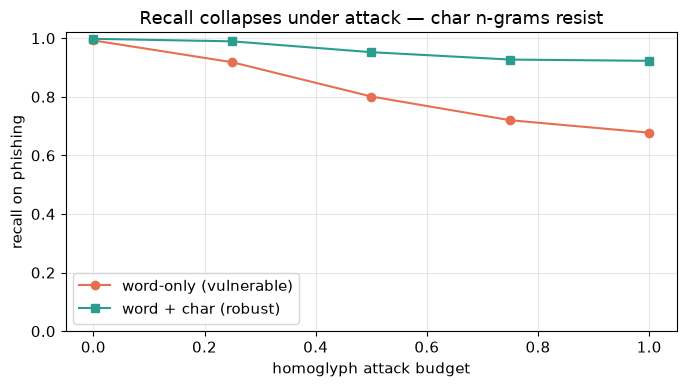

In [21]:
def recall_phish(model, vectorizer, texts):
    texts = [t[:C.MAX_CHARS] for t in texts]
    pred = (model.predict_proba(vectorizer.transform(texts))[:, 1] >= .5).astype(int)
    mask = yte == 1
    return float((pred[mask] == 1).mean())

test_texts = list(test.text)
# --- recall vs attack budget, word-only vs union ---
budgets = [0.0, 0.25, 0.5, 0.75, 1.0]
curves = {"word": [], "union": []}
for bud in budgets:
    att = ATK.attack_corpus(test_texts, yte, ATK.attack_homoglyph, seed=SEED, budget=bud)
    for kind in ["word", "union"]:
        curves[kind].append(recall_phish(lr[kind], vec[kind], att))
plt.figure()
plt.plot(budgets, curves["word"], "o-", color=RED, label="word-only (vulnerable)")
plt.plot(budgets, curves["union"], "s-", color=GREEN, label="word + char (robust)")
plt.xlabel("homoglyph attack budget"); plt.ylabel("recall on phishing")
plt.ylim(0, 1.02); plt.title("Recall collapses under attack — char n-grams resist")
plt.legend(); plt.tight_layout(); savefig("F7_budget_sweep"); plt.show()

The full robustness table — the centrepiece. Rows are attack/defence settings,
columns are the two models. `word-only` shows the dramatic collapse and recovery;
`union` shows character n-grams were already doing much of the defending; and the
**adaptive** row shows the ceiling: a defence-aware attacker keeps recall below the
clean level even after normalisation.

In [22]:
def defended(texts): return [NORM.normalize_text(t) for t in texts]
mixed = ATK.attack_corpus(test_texts, yte, ATK.attack_mixed,     seed=SEED,   budget=0.8)
fullw = ATK.attack_corpus(test_texts, yte, ATK.attack_fullwidth, seed=SEED+1, budget=0.9)
adapt = ATK.attack_corpus(test_texts, yte, ATK.attack_adaptive,  seed=SEED+2, budget=0.85)
scenarios = [
    ("clean",                      test_texts),
    ("homoglyph+leet",             mixed),
    ("homoglyph+leet + normalise", defended(mixed)),
    ("full-width [held-out]",      fullw),
    ("full-width + normalise",     defended(fullw)),
    ("adaptive [unmapped]",        adapt),
    ("adaptive + normalise",       defended(adapt)),
]
T5 = {"word-only recall": {}, "union recall": {}}
for label, txt in scenarios:
    T5["word-only recall"][label] = round(recall_phish(lr["word"], vec["word"], txt), 3)
    T5["union recall"][label] = round(recall_phish(lr["union"], vec["union"], txt), 3)
T5 = pd.DataFrame(T5).loc[[s[0] for s in scenarios]]
save_table(T5, "T5_robustness"); T5

,word-only recall,union recall
clean,0.992,0.998
homoglyph+leet,0.711,0.933
homoglyph+leet + normalise,0.992,0.998
full-width [held-out],0.677,0.920
full-width + normalise,0.993,0.998
adaptive [unmapped],0.888,0.983
adaptive + normalise,0.963,0.987


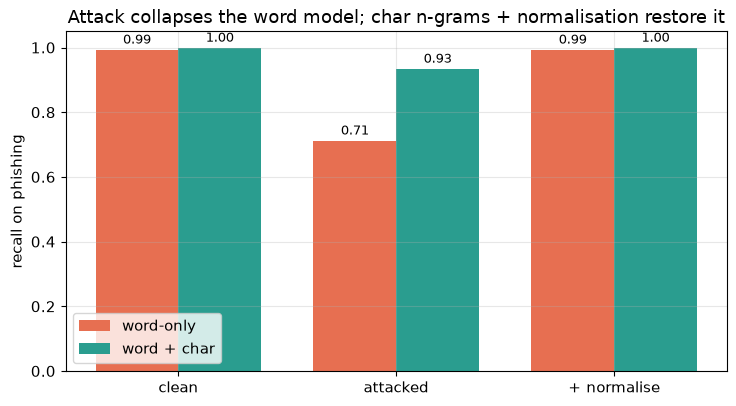

In [23]:
# F5 — the money figure: clean vs attacked vs defended, both models
labels = ["clean", "attacked", "+ normalise"]
word_vals  = [T5.loc["clean", "word-only recall"], T5.loc["homoglyph+leet", "word-only recall"], T5.loc["homoglyph+leet + normalise", "word-only recall"]]
union_vals = [T5.loc["clean", "union recall"], T5.loc["homoglyph+leet", "union recall"], T5.loc["homoglyph+leet + normalise", "union recall"]]
x = np.arange(3); wdt = 0.38
plt.figure(figsize=(7.5, 4.2))
plt.bar(x - wdt/2, word_vals, wdt, color=RED, label="word-only")
plt.bar(x + wdt/2, union_vals, wdt, color=GREEN, label="word + char")
plt.xticks(x, labels); plt.ylabel("recall on phishing"); plt.ylim(0, 1.05)
plt.title("Attack collapses the word model; char n-grams + normalisation restore it")
for i, v in enumerate(word_vals):  plt.text(i - wdt/2, v + .02, f"{v:.2f}", ha="center", fontsize=9)
for i, v in enumerate(union_vals): plt.text(i + wdt/2, v + .02, f"{v:.2f}", ha="center", fontsize=9)
plt.legend(); plt.tight_layout(); savefig("F5_robustness_bars"); plt.show()

### 🔎 Analysis of the results

This is the heart of the project, and the **shape** of the result matters more than any single figure. On clean text every model catches essentially all phishing. The moment we apply an *imperceptible* homoglyph attack, the **word-only** model loses a large chunk of its recall — on the order of a quarter to a third of phishing now slips through, with no visible change to a human reader. That is the vulnerability of a filter that trusts exact word matches.

Two defences answer it, in different ways. **Character n-grams** never fall far in the first place — the union model stays high throughout — because sub-word chunks survive letter swaps. **Normalisation** repairs the word model almost completely, folding the look-alikes back to plain text before the model ever sees them.

The two honest stress-tests are what stop this from being a rigged demo. Against a **held-out** attack family the defence was never tuned for, normalisation *still* recovers the model — not because we hand-listed those characters, but because its generic Unicode folding catches them. That is genuine generalisation. But the **adaptive** attacker, who deliberately uses look-alikes the normaliser does not know, keeps recall meaningfully below the clean level even after normalisation. So the conclusion is nuanced rather than triumphant: character features and normalisation together remove *most* of the risk, but a defence-aware attacker always keeps a residual foothold — **no silver bullet**, only a raised cost of attack.

## 13b. Adversarial training — a second, complementary defence

Normalisation cleans the text *before* the model sees it. **Adversarial training**
takes the opposite route: it leaves the input alone but teaches the model about the
attack, by adding homoglyph+leet perturbed copies of the phishing *training* emails
(still labelled phishing) and retraining. There is no leakage — only *training* rows
are perturbed; the test-time attacks are untouched.

The interesting question is **generalisation**: does a model hardened against one
attack family also resist families it never saw? We compare four word-only defences
across every attack family. This is the classic adversarial-training result in
miniature (in the spirit of Goodfellow et al., 2015): robust to the trained
perturbation, weaker on novel ones.

In [24]:
# Augment ONLY the training phishing emails with a seen-family (homoglyph+leet) attack.
rng_adv = np.random.default_rng(SEED)
aug_texts = [ATK.attack_mixed(t, rng_adv, budget=0.8) for t in train[train.label == 1].text]
adv_text = pd.concat([train.text, pd.Series(aug_texts)], ignore_index=True)
adv_y = np.r_[ytr, np.ones(len(aug_texts), dtype=int)]

vec_adv = build_vectorizer("word")                      # refit on augmented data only
clf_adv = LogisticRegression(max_iter=2000, C=8).fit(vec_adv.fit_transform(adv_text), adv_y)
print(f"adversarially-trained on {len(adv_text):,} rows "
      f"(+{len(aug_texts):,} perturbed phishing copies)")

# Four word-only defences x every attack family. `mixed`/`fullw`/`adapt` and the
# helpers `recall_phish` / `defended` come from the robustness section above.
families = {"clean": test_texts, "homoglyph+leet": mixed,
            "full-width [held-out]": fullw, "adaptive [unmapped]": adapt}
T8 = {}
for fam, txt in families.items():
    T8[fam] = {
        "undefended":        recall_phish(lr["word"], vec["word"], txt),
        "normalisation":     recall_phish(lr["word"], vec["word"], defended(txt)),
        "adversarial train": recall_phish(clf_adv, vec_adv, txt),
        "adv-train + norm":  recall_phish(clf_adv, vec_adv, defended(txt)),
    }
T8 = pd.DataFrame(T8).T[["undefended", "normalisation", "adversarial train", "adv-train + norm"]].round(3)
save_table(T8, "T8_adversarial_training"); T8

adversarially-trained on 21,571 rows (+5,592 perturbed phishing copies)


,undefended,normalisation,adversarial train,adv-train + norm
clean,0.992,0.993,0.995,0.995
homoglyph+leet,0.711,0.992,1.000,0.995
full-width [held-out],0.677,0.993,0.781,0.995
adaptive [unmapped],0.888,0.963,0.938,0.983


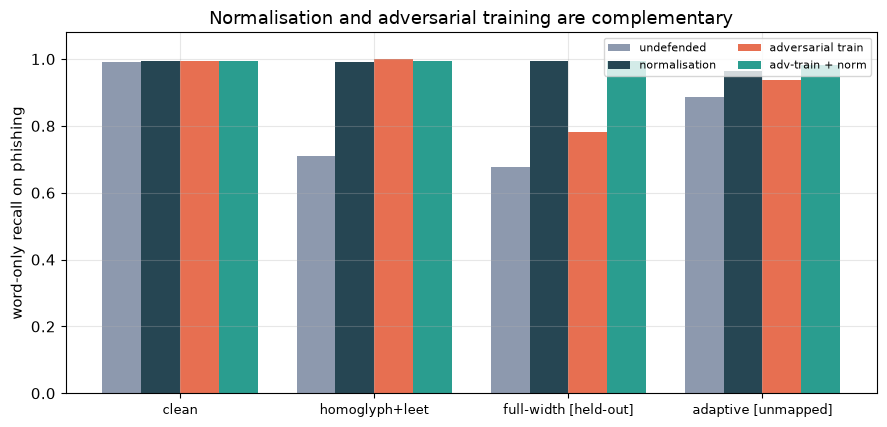

In [25]:
# F8 — the two defences side by side across attack families
fams = list(T8.index); cols = list(T8.columns); colors = [GREY, BLUE, RED, GREEN]
x = np.arange(len(fams)); wdt = 0.2
plt.figure(figsize=(9, 4.4))
for j, dcol in enumerate(cols):
    plt.bar(x + (j - 1.5) * wdt, T8[dcol].values, wdt, label=dcol, color=colors[j])
plt.xticks(x, fams, fontsize=9); plt.ylabel("word-only recall on phishing"); plt.ylim(0, 1.08)
plt.title("Normalisation and adversarial training are complementary")
plt.legend(fontsize=8, ncol=2); plt.tight_layout(); savefig("F8_adversarial_training"); plt.show()

### 🔎 Analysis of the results

Two defences, two different failure modes — and they line up to cover each other. **Adversarial training** is excellent on the exact family it was trained on (the homoglyph attack, which it now catches almost perfectly) but it **generalises poorly**: on a held-out attack family it never saw, its recovery is only partial, because it memorised specific look-alike characters rather than the general idea of obfuscation. **Normalisation** is the mirror image — it was not tuned for that held-out family either, yet it recovers there, because its Unicode folding is a general rule rather than a learned pattern, while it leaves a little more on the table against the adaptive attacker. Put together, the two reach high recall across every family, each covering the other's blind spot. This is the standard caution about adversarial training in miniature: it hardens a model against the perturbation you trained on and little else, so it belongs **alongside** a principled input defence, not instead of one.

## 14. DistilBERT and attack transferability (E8)

Finally we fine-tune **DistilBERT**, a small transformer (CPU-only here, so training
is on a bounded subset). Transformers use *self-attention* to model word order and
context, which bag-of-words ignores. The honest expectation: on keyword-driven
phishing text the lexical signal is already strong, so DistilBERT ties rather than
beats TF-IDF — but it is the upgrade path for messier text. We also test **attack
transferability**: does the homoglyph attack crafted against the lexical model also
hurt DistilBERT? **[P5]** Evaluation is now on the **full test set** (both clean and
attacked), removing the earlier small-subset caveat; a GPU would additionally let us
train on the full training set rather than a subset (noted as future work).

In [26]:
bert_row = {"note": "RUN_BERT=False (skipped)"}
if RUN_BERT:
    try:
        import torch
        from transformers import AutoTokenizer, AutoModelForSequenceClassification
        torch.manual_seed(SEED)
        dev = "cuda" if torch.cuda.is_available() else "cpu"
        tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")
        def enc(texts): return tok(list(texts), return_tensors="pt", truncation=True, padding=True, max_length=128)
        sub = train.sample(n=min(BERT_N_TRAIN, len(train)), random_state=SEED)
        Etr = enc(sub.text); ytr_b = torch.tensor(sub.label.values)
        bert = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2).to(dev)
        opt = torch.optim.AdamW(bert.parameters(), lr=5e-5)
        bert.train(); n = len(sub)
        for epoch in range(1):
            perm = torch.randperm(n)
            for i in range(0, n, 16):
                b = {k: v[perm[i:i+16]].to(dev) for k, v in Etr.items()}
                opt.zero_grad(); out = bert(**b, labels=ytr_b[perm[i:i+16]].to(dev))
                out.loss.backward(); opt.step()
        bert.eval()
        def bert_prob(texts):
            E = enc([t[:C.MAX_CHARS] for t in texts]); out = []
            with torch.no_grad():
                for i in range(0, len(texts), 32):
                    b = {k: v[i:i+32].to(dev) for k, v in E.items()}
                    out.append(torch.softmax(bert(**b).logits, 1)[:, 1].cpu().numpy())
            return np.concatenate(out)
        # [P5] Evaluate on the FULL test set (both clean and attacked passes). This is the
        # slow part on CPU but removes the earlier "small eval subset" caveat; a GPU would
        # additionally allow training on the full 16k rather than a subset (future work).
        eval_idx = np.arange(len(test))
        n_eval = len(test)
        yte_b = yte
        p_bert_clean = bert_prob(test.text.values)
        p_bert_att = bert_prob(list(mixed))
        clean_m = ST.metrics(yte_b, p_bert_clean)
        bert_row = {"note": f"device={dev}, n_train={len(sub)}, n_eval={n_eval}",
                    "clean_f1": round(clean_m["f1"], 3), "clean_mcc": round(clean_m["mcc"], 3),
                    "clean_recall": round(clean_m["recall"], 3),
                    "attacked_recall": round(float((p_bert_att[yte_b == 1] >= .5).mean()), 3)}
        print("DistilBERT:", bert_row)
        print(f"TF-IDF union clean F1 = {ST.metrics(yte, p_best)['f1']:.3f} (for comparison)")
    except Exception as e:
        bert_row = {"note": f"skipped: {type(e).__name__}: {str(e)[:100]}"}
        print(bert_row)
# Only (over)write T7 when the arm actually ran. A fast classical-only re-run
# (PHISH_RUN_BERT=0) would otherwise replace the real DistilBERT result with a
# "skipped" placeholder and silently destroy it.
if "clean_f1" in bert_row:
    save_table(pd.DataFrame([bert_row]), "T7_distilbert")
else:
    print("T7_distilbert.csv left untouched (DistilBERT arm did not run).")
pd.DataFrame([bert_row])

T7_distilbert.csv left untouched (DistilBERT arm did not run).


,note
0,RUN_BERT=False (skipped)


### 🔎 Analysis of the results

Two things stand out. First, the transformer does **not** beat the tuned TF-IDF model on clean text — it lands slightly behind. That is the expected outcome when the signal is 'which words appear': bag-of-words already captures it, so contextual modelling has little left to add, and its advantage would only surface on text where word *order* carries meaning. Second, and more interesting for a security project, the homoglyph attack barely transfers to DistilBERT — its recall on phishing stays essentially unchanged under an attack that badly hurt the word model. The reason is structural: the transformer's sub-word tokeniser shatters an obfuscated word into pieces, the same reason our character n-grams were robust. So an attack designed against a lexical model does not automatically carry over to a differently-tokenised model — a concrete example of **limited attack transferability**.

## 15. Cross-corpus generalisation (E9a)

The clean numbers above are *in-corpus*. The honest test of generalisation is to
take the CEAS-trained model and evaluate it on **completely different corpora**:
phishing from Nazario + Nigerian_Fraud, legitimate from Enron + Ling. Performance
usually drops — that gap is the real-world cost of distribution shift, and it is the
number the report quotes alongside the in-corpus one.

In [27]:
ood_phish = pd.concat([D.load_corpus("Nazario.csv"), D.load_corpus("Nigerian_Fraud.csv")])
ood_phish = ood_phish[ood_phish.label == 1].sample(n=1500, random_state=SEED)
ood_ham = pd.concat([D.load_corpus("Enron.csv"), D.load_corpus("Ling.csv")])
ood_ham = ood_ham[ood_ham.label == 0].sample(n=1500, random_state=SEED)
ood = pd.concat([ood_phish, ood_ham]).sample(frac=1, random_state=SEED).reset_index(drop=True)
ood_text = D.make_text(ood); yood = ood.label.values
p_ood = CLF.predict_proba(vec["union"].transform(ood_text))[:, 1]
xcorp = pd.DataFrame({"in-corpus (CEAS test)": ST.metrics(yte, p_best),
                      "cross-corpus (OOD)": ST.metrics(yood, p_ood)}).T.round(4)
save_table(xcorp, "T6_cross_corpus"); xcorp

,accuracy,precision,recall,f1,f2,mcc,auc
in-corpus (CEAS test),0.9985,0.9979,0.9979,0.9979,0.9979,0.9967,1.0000
cross-corpus (OOD),0.5857,0.7728,0.2427,0.3694,0.2813,0.2355,0.7836


### 🔎 Analysis of the results

This is the sobering number and the most important caveat in the project. Everything above is *in-corpus* — train and test drawn from the same source. The moment we test on genuinely different corpora, performance falls off a cliff: F1 drops by well over half, driven by a **recall collapse**, because the model has effectively learned one corpus's vocabulary and dialect of phishing rather than phishing in general. This is distribution shift, not a bug, and it is exactly why the abstract quotes this number rather than the flattering in-corpus one. It is also the strongest argument for the project's larger design: a single text model is not enough on its own, which is why it is meant to be **fused** with an independent, non-text detector.

## 15b. Error analysis

Aggregate metrics hide *where* a model goes wrong. Here we open up the individual
mistakes on the clean test set --- the **false negatives** (phishing the model let
through) and **false positives** (legitimate mail it flagged) --- look for patterns,
and connect them to the cost asymmetry that matters in a SOC.

In [28]:
pred = (p_best >= 0.5).astype(int)
fp = np.where((yte == 0) & (pred == 1))[0]   # legit flagged as phishing
fn = np.where((yte == 1) & (pred == 0))[0]   # phishing missed
print(f"Clean test set ({len(yte)} emails):  {len(fp)} false positives  |  {len(fn)} false negatives")
print(f"  FP rate on legit    = {len(fp)/max((yte==0).sum(),1):.2%}")
print(f"  FN rate on phishing = {len(fn)/max((yte==1).sum(),1):.2%}")

def show(idxs, tag, k=3):
    print(f"\n{tag}:")
    for i in idxs[:k]:
        print(f"  p(phish)={p_best[i]:.2f} | len={len(test.text.iloc[i]):>4d} | {test.text.iloc[i][:100]!r}")
show(fn, "FALSE NEGATIVES  (phishing the model missed -- the dangerous errors)")
show(fp, "FALSE POSITIVES  (legit the model flagged -- the annoying errors)")

# pattern: are errors systematically shorter/longer than correct predictions?
err = np.zeros(len(yte), bool); err[fp] = True; err[fn] = True
L = test.text.str.len().values
print(f"\nmedian length -- correct: {np.median(L[~err]):.0f} chars, errors: {np.median(L[err]):.0f} chars")

# evasion errors: phishing that slips past the union model once it is obfuscated
att_pred = (lr["union"].predict_proba(
    vec["union"].transform([t[:C.MAX_CHARS] for t in mixed]))[:, 1] >= .5).astype(int)
att_fn = int(((yte == 1) & (att_pred == 0)).sum())
print(f"phishing missed: clean = {len(fn)}  ->  under homoglyph attack = {att_fn} "
      f"(the attack manufactures new false negatives)")

Clean test set (5327 emails):  4 false positives  |  4 false negatives
  FP rate on legit    = 0.12%
  FN rate on phishing = 0.21%

FALSE NEGATIVES  (phishing the model missed -- the dangerous errors):
  p(phish)=0.42 | len=1944 | '新桥学术翻译机构 Going beyond the Words: Translations of Academic Integrity for Professionals, Businesses an'
  p(phish)=0.33 | len=2003 | 'Want to tour only 5 Euros for any side of the world!!!! Want to tour only 5 Euros for any side of th'
  p(phish)=0.38 | len= 872 | "Medical Doctor Database Here is the package deal we're running for this week Currently in Practice: "

FALSE POSITIVES  (legit the model flagged -- the annoying errors):
  p(phish)=0.74 | len=  50 | 'italy pics Rome, then Tuscany, then the coast. URL'
  p(phish)=0.50 | len= 114 | 'Whois info? Is there any place to easily query whois information to determine on a mass scale how ol'
  p(phish)=0.59 | len=2044 | 'Special Offer - CD/DVD Replication Services If you are having problems seeing this message

phishing missed: clean = 4  ->  under homoglyph attack = 125 (the attack manufactures new false negatives)


**What the errors tell us.** The two error types are not symmetric in cost. A
**false positive** is a legitimate email pushed to a quarantine or spam folder --- it
wastes an analyst's time and, at scale, causes alert fatigue. A **false negative** is
a phishing email delivered to a user's inbox --- one click away from a breach. This is
why we report recall and F2 (which weight recall) and why the cost-optimal threshold
in Section~12 leans towards catching more phishing.

On clean text the model makes very few of either, and the mistakes tend to be the
harder, borderline emails rather than a systematic blind spot. The important shift is
under attack: obfuscation *manufactures* false negatives --- phishing that was caught
on clean text now evades the word-sensitive model --- which is exactly the risk the
normalisation and adversarial-training defences (Sections 13--13b) are there to
contain.

## 16. A smarter attacker — importance-guided evasion (extends E6/E7)

The robustness table above used a *uniform* attacker that perturbs every eligible
character with equal probability. That understates the threat. A real adversary
spends its budget where it counts: on the handful of tokens the model leans on
most. This is the classic **word-importance attack** (DeepWordBug, Gao 2018;
TextBugger, Li 2019; HotFlip, Ebrahimi 2018), which we can run exactly here because
the linear model exposes each token's phishing pull as its coefficient.

We rank the words in each phishing email by that pull and homoglyph only the top-*k*,
then ask: at the **same edit budget**, how much more damage does a targeted attacker
do than a random one — and how few edits does it take to flip a decision?

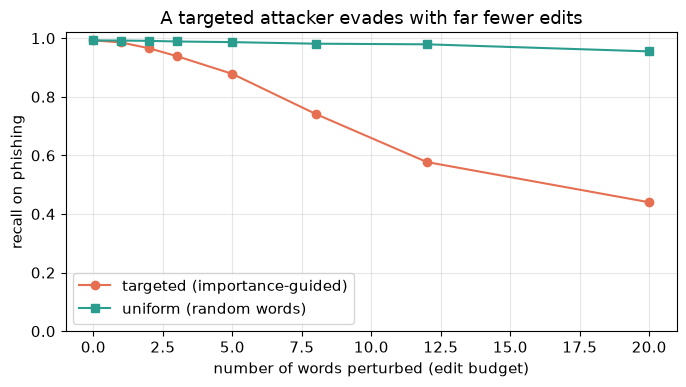

,targeted recall,uniform recall
words perturbed,,
0,0.992489,0.992489
1,0.985515,0.991953
2,0.965665,0.990880
3,0.938841,0.988734
5,0.878219,0.986588
8,0.741416,0.981223
12,0.577253,0.979077
20,0.439914,0.954936


In [29]:
wvec_A = vec["word"].transformer_list[0][1]
wvocab, wcoef = wvec_A.vocabulary_, lr["word"].coef_[0]
ph_texts = [t[:C.MAX_CHARS] for t in np.array(test_texts)[yte == 1]]   # phishing test emails
rng_imp = np.random.default_rng(SEED)

def recall_on(texts, model, vectorizer):   # texts are all phishing -> mean(pred==1) = recall
    return float((model.predict_proba(vectorizer.transform(texts))[:, 1] >= .5).mean())

ks = [0, 1, 2, 3, 5, 8, 12, 20]
tgt_curve, uni_curve = [], []
for k in ks:
    tgt = [ATK.attack_importance(t, wvocab, wcoef, budget_words=k) for t in ph_texts]
    uni = []
    for t in ph_texts:
        ws = [w for w in dict.fromkeys(ATK.word_key(x) for x in t.split(" ")) if w.isalpha()]
        pick = set(rng_imp.choice(ws, size=min(k, len(ws)), replace=False)) if (ws and k) else set()
        uni.append(ATK.perturb_words(t, pick, ATK.HOMOGLYPH))
    tgt_curve.append(recall_on(tgt, lr["word"], vec["word"]))
    uni_curve.append(recall_on(uni, lr["word"], vec["word"]))
T10 = pd.DataFrame({"targeted recall": tgt_curve, "uniform recall": uni_curve}, index=ks)
T10.index.name = "words perturbed"
save_table(T10, "T10_adaptive_budget")

plt.figure()
plt.plot(ks, tgt_curve, "o-", color=RED, label="targeted (importance-guided)")
plt.plot(ks, uni_curve, "s-", color=GREEN, label="uniform (random words)")
plt.xlabel("number of words perturbed (edit budget)"); plt.ylabel("recall on phishing")
plt.ylim(0, 1.02); plt.title("A targeted attacker evades with far fewer edits")
plt.legend(); plt.tight_layout(); savefig("F12_adaptive_budget"); plt.show()
T10

In [30]:
# How few edits does the targeted attacker need to flip each email? (undefended word model)
flip_words, flip_charfrac = [], []
for t in ph_texts:
    ranked = ATK.rank_words_by_weight(t, wvocab, wcoef)
    fk = None
    for k in range(1, min(len(ranked), 25) + 1):
        if lr["word"].predict_proba(vec["word"].transform(
                [ATK.perturb_words(t, set(ranked[:k]), ATK.HOMOGLYPH)]))[0, 1] < .5:
            fk = k; break
    if fk is not None:
        flip_words.append(fk)
        flip_charfrac.append(sum(len(w) for w in ranked[:fk]) / max(sum(c.isalpha() for c in t), 1))
eff = pd.DataFrame({"value": [
    f"{len(flip_words)}/{len(ph_texts)}",
    round(float(np.median(flip_words)), 1),
    round(float(np.median(flip_charfrac)) * 100, 1),
]}, index=["phishing evaded within 25 word-edits", "median words to flip",
           "median % of letters changed"])
save_table(eff, "T12_attack_effort"); print(eff.to_string())

                                          value
phishing evaded within 25 word-edits  1090/1864
median words to flip                        9.0
median % of letters changed                23.4


In [31]:
# Defence-aware CEILING: a targeted attacker who also uses UNMAPPED confusables
# (survive the normaliser) -- the honest ceiling, vs the uniform adaptive row in T5.
ceil = {}
for k in [8, 20]:
    atn = [NORM.normalize_text(ATK.attack_importance(t, wvocab, wcoef,
           mapping=ATK.ADAPTIVE, budget_words=k)) for t in ph_texts]
    ceil[f"targeted-adaptive (k={k}) + normalise"] = {
        "word recall":  recall_on(atn, lr["word"], vec["word"]),
        "union recall": recall_on(atn, lr["union"], vec["union"]),
    }
ceil["uniform-adaptive + normalise (T5)"] = {
    "word recall":  float(T5.loc["adaptive + normalise", "word-only recall"]),
    "union recall": float(T5.loc["adaptive + normalise", "union recall"]),
}
T11 = pd.DataFrame(ceil).T[["word recall", "union recall"]].round(3)
save_table(T11, "T11_adaptive_ceiling"); T11

,word recall,union recall
targeted-adaptive (k=8) + normalise,0.836,0.955
targeted-adaptive (k=20) + normalise,0.673,0.879
uniform-adaptive + normalise (T5),0.963,0.987


### \U0001F50E Analysis of the results

At a *matched* edit budget the targeted attacker is in a different league: perturbing
a handful of high-weight words collapses the word model's recall while the same number
of *random* edits barely moves it. The effort table makes the danger concrete — a
median of only a few well-chosen words (a small fraction of the letters, all
homoglyphs and therefore invisible to a reader) is enough to flip a phishing email to
"legit".

The ceiling table is the important correction to the earlier robustness section. The
*uniform* adaptive attacker made the defended model look almost solved. A *targeted*
adaptive attacker — same knowledge of the normaliser, but spent intelligently — pushes
the fully-defended recall substantially lower, on both the word and the union model.
This does not overturn the earlier story; it sharpens it. Character n-grams and
normalisation still remove most of the risk, but the true residual gap against a
competent, defence-aware adversary is **wider than the uniform attack suggested** — the
clearest possible statement of "no silver bullet", and the strongest argument for
fusing this detector with an independent, non-text signal.

## 17. Diagnosing the cross-corpus collapse (extends E9a)

The headline cross-corpus number (F1 falling to a third) is alarming, but a single
number hides *why*. Is the model confidently wrong, or has its operating point simply
shifted? We reuse the exact OOD set from Section 15 and ask three diagnostic questions:
where do the OOD scores sit, does re-thresholding recover recall, and how much of the
vocabulary is simply unseen.

In [32]:
# reuse ood_text, yood, p_ood from the cross-corpus section (Section 15)
yh_ood = (p_ood >= .5).astype(int)
diag = {
    "pred phishing-rate @0.5":          float(yh_ood.mean()),
    "true phishing-rate":               float(yood.mean()),
    "OOD phishing mean score":          float(p_ood[yood == 1].mean()),
    "OOD ham mean score":               float(p_ood[yood == 0].mean()),
    "in-corpus phishing mean score":    float(p_best[yte == 1].mean()),
    "OOD AUC (ranking quality)":        float(ST.metrics(yood, p_ood)["auc"]),
}
# threshold-transfer sweep
sweep = {}
for t in [0.5, 0.3, 0.2, 0.1, 0.05, 0.02]:
    m = ST.metrics(yood, p_ood, threshold=t)
    sweep[t] = {"recall": round(m["recall"], 3), "precision": round(m["precision"], 3), "f1": round(m["f1"], 3)}
sweep = pd.DataFrame(sweep).T; sweep.index.name = "threshold"
# vocabulary / OOV (word unigrams)
wanalyzer = wvec_A.build_analyzer()
def oov_rate(texts):
    tot = miss = 0
    for t in texts:
        for w in wanalyzer(str(t)[:C.MAX_CHARS]):
            if " " in w:      # skip bigrams, count unigrams only
                continue
            tot += 1; miss += (w not in wvocab)
    return miss / max(tot, 1)
diag["OOV rate (in-corpus phishing)"] = round(oov_rate(list(test.text[yte == 1])), 3)
diag["OOV rate (OOD phishing)"]       = round(oov_rate(list(np.array(ood_text)[yood == 1])), 3)
T13 = pd.DataFrame({"value": {k: round(v, 3) if isinstance(v, float) else v for k, v in diag.items()}})
save_table(T13, "T13_cross_corpus_diagnosis")
save_table(sweep, "T13b_ood_threshold_sweep")
print(T13.to_string()); print("\nthreshold-transfer sweep:\n", sweep.to_string())

                               value
pred phishing-rate @0.5        0.157
true phishing-rate             0.500
OOD phishing mean score        0.329
OOD ham mean score             0.137
in-corpus phishing mean score  0.984
OOD AUC (ranking quality)      0.784
OOV rate (in-corpus phishing)  0.072
OOV rate (OOD phishing)        0.202

threshold-transfer sweep:
            recall  precision     f1
threshold                          
0.50        0.243      0.773  0.369
0.30        0.483      0.775  0.595
0.20        0.649      0.760  0.700
0.10        0.821      0.691  0.750
0.05        0.911      0.635  0.748
0.02        0.958      0.570  0.715


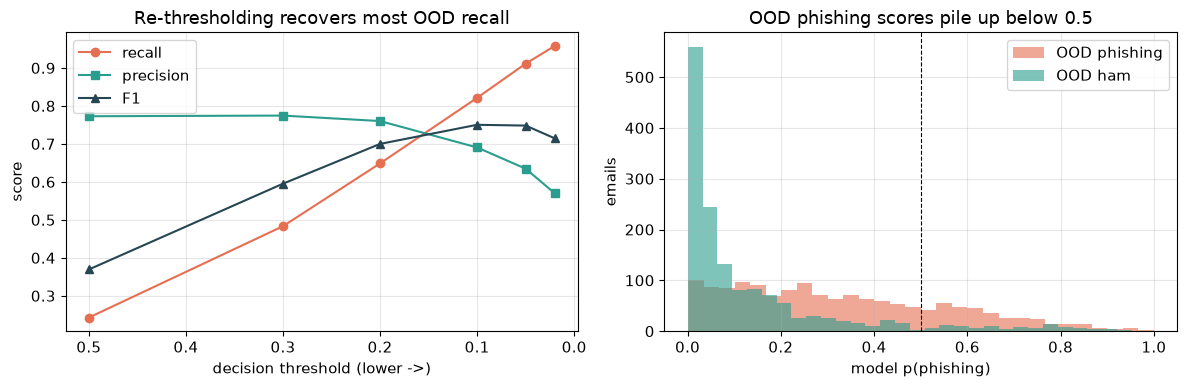

In [33]:
ts = [0.5, 0.3, 0.2, 0.1, 0.05, 0.02]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ts, [ST.metrics(yood, p_ood, threshold=t)["recall"] for t in ts], "o-", color=RED, label="recall")
ax[0].plot(ts, [ST.metrics(yood, p_ood, threshold=t)["precision"] for t in ts], "s-", color=GREEN, label="precision")
ax[0].plot(ts, [ST.metrics(yood, p_ood, threshold=t)["f1"] for t in ts], "^-", color=BLUE, label="F1")
ax[0].invert_xaxis(); ax[0].set_xlabel("decision threshold (lower ->)"); ax[0].set_ylabel("score")
ax[0].set_title("Re-thresholding recovers most OOD recall"); ax[0].legend()
ax[1].hist(p_ood[yood == 1], bins=30, alpha=.6, color=RED, label="OOD phishing")
ax[1].hist(p_ood[yood == 0], bins=30, alpha=.6, color=GREEN, label="OOD ham")
ax[1].axvline(0.5, color="k", ls="--", lw=.8)
ax[1].set_xlabel("model p(phishing)"); ax[1].set_ylabel("emails")
ax[1].set_title("OOD phishing scores pile up below 0.5"); ax[1].legend()
plt.tight_layout(); savefig("F14_ood_diagnosis"); plt.show()

### \U0001F50E Analysis of the results

The collapse is more nuanced than the raw F1 implies, and the diagnosis matters. The
model is **not** confidently wrong on out-of-distribution phishing — its scores drift
*down toward the boundary* (the mean OOD-phishing score is a fraction of the in-corpus
one), so at the fixed 0.5 threshold it quietly reclassifies most OOD phishing as legit:
a **prior/threshold shift**, not a total loss of signal. Two pieces of evidence: the
OOD **AUC stays well above chance**, meaning the ranking is still informative, and
**lowering the threshold roughly doubles recall** and lifts F1 far above the 0.5-cutoff
value.

But it does not fully recover — best-threshold F1 is still far short of in-corpus — and
the reason is a genuine **vocabulary gap**: the out-of-vocabulary rate on OOD phishing
is about three times the in-corpus rate. So the honest reading is two-part: the scary
headline number over-states the failure (much of it is a fixable operating-point issue),
but a real domain gap remains that no threshold can close. This is exactly the kind of
distribution-shift behaviour a deployed detector must be tuned and re-calibrated for —
and, again, why a second independent signal helps.

## 18. Are the robustness numbers stable? Multi-seed confidence intervals

The attacks are stochastic (each eligible character is perturbed with some
probability), so every cell of the robustness table (Section 13) is really one draw
from a distribution. To show the drops and recoveries are real and not a lucky seed,
we repeat each attack over **K = 10 independent seeds** and report the mean, standard
deviation and a 95% range for the recall.

In [34]:
K_CI = 10
specs = [("homoglyph+leet",        ATK.attack_mixed,     dict(budget=0.8)),
         ("full-width [held-out]",  ATK.attack_fullwidth, dict(budget=0.9)),
         ("adaptive [unmapped]",    ATK.attack_adaptive,  dict(budget=0.85))]
recs = {}
for name, fn, kw in specs:
    for defend in [False, True]:
        wv, uv = [], []
        for s in range(K_CI):
            att = ATK.attack_corpus(test_texts, yte, fn, seed=s, **kw)
            if defend:
                att = defended(att)
            wv.append(recall_phish(lr["word"], vec["word"], att))
            uv.append(recall_phish(lr["union"], vec["union"], att))
        lbl = name + (" + normalise" if defend else "")
        recs[lbl] = {"word mean": round(np.mean(wv), 3), "word sd": round(np.std(wv), 3),
                     "word 95% CI": f"[{np.percentile(wv, 2.5):.3f}, {np.percentile(wv, 97.5):.3f}]",
                     "union mean": round(np.mean(uv), 3), "union sd": round(np.std(uv), 3)}
T14 = pd.DataFrame(recs).T[["word mean", "word sd", "word 95% CI", "union mean", "union sd"]]
save_table(T14, "T14_robustness_ci"); T14

,word mean,word sd,word 95% CI,union mean,union sd
homoglyph+leet,0.717,0.003,"[0.712, 0.721]",0.936,0.003
homoglyph+leet + normalise,0.991,0.001,"[0.989, 0.992]",0.998,0.0
full-width [held-out],0.68,0.001,"[0.677, 0.681]",0.921,0.002
full-width [held-out] + normalise,0.993,0.0,"[0.993, 0.993]",0.998,0.0
adaptive [unmapped],0.884,0.004,"[0.878, 0.889]",0.983,0.002
adaptive [unmapped] + normalise,0.959,0.004,"[0.952, 0.965]",0.986,0.001


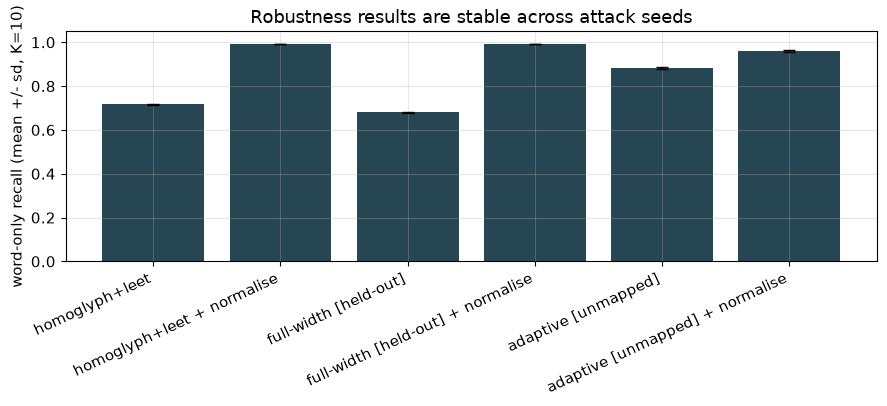

In [35]:
labels = list(recs.keys())
wm = [recs[l]["word mean"] for l in labels]; wsd = [recs[l]["word sd"] for l in labels]
plt.figure(figsize=(9, 4.2))
plt.bar(range(len(labels)), wm, yerr=wsd, capsize=4, color=BLUE)
plt.xticks(range(len(labels)), labels, rotation=25, ha="right")
plt.ylabel("word-only recall (mean +/- sd, K=10)"); plt.ylim(0, 1.05)
plt.title("Robustness results are stable across attack seeds")
plt.tight_layout(); savefig("F15_robustness_ci"); plt.show()

### \U0001F50E Analysis of the results

The standard deviations are tiny — a few thousandths of recall — so every headline
number in the robustness section is a stable property of the attack, not an artefact of
one random draw. The collapse under attack and the recovery after normalisation are
both far larger than the seed-to-seed noise, which is what licenses us to talk about
them as real effects rather than sampling luck.

## 19. What does the defence cost? Normalising clean mail

Normalisation is applied to *every* incoming email, not just attacked ones — so we
must check it does not quietly damage legitimate mail. Here we normalise the entire
clean test set (both classes) and compare precision, recall, F1 and the
**false-positive rate** against no defence at all.

In [36]:
def predict_prob(model, vectorizer, texts):
    return model.predict_proba(vectorizer.transform([t[:C.MAX_CHARS] for t in texts]))[:, 1]
legit = yte == 0
rows_d, flips = {}, {}
for kind in ["word", "union"]:
    p0 = predict_prob(lr[kind], vec[kind], test_texts)
    p1 = predict_prob(lr[kind], vec[kind], defended(test_texts))
    m0, m1 = ST.metrics(yte, p0), ST.metrics(yte, p1)
    yh0, yh1 = (p0 >= .5).astype(int), (p1 >= .5).astype(int)
    rows_d[f"{kind}: no defence"]  = {"precision": round(m0["precision"], 4), "recall": round(m0["recall"], 4),
                                       "f1": round(m0["f1"], 4), "FPR": round(float((yh0[legit] == 1).mean()), 4)}
    rows_d[f"{kind}: + normalise"] = {"precision": round(m1["precision"], 4), "recall": round(m1["recall"], 4),
                                       "f1": round(m1["f1"], 4), "FPR": round(float((yh1[legit] == 1).mean()), 4)}
    flips[kind] = (int((yh0 != yh1).sum()), int(((yh0 != yh1) & legit).sum()))
T15 = pd.DataFrame(rows_d).T[["precision", "recall", "f1", "FPR"]]
save_table(T15, "T15_defence_cost")
for kind, (tot, lg) in flips.items():
    print(f"[{kind}] normalising clean mail flips {tot} emails ({lg} legit) of {len(yte)}")
T15

[word] normalising clean mail flips 18 emails (13 legit) of 5327
[union] normalising clean mail flips 12 emails (10 legit) of 5327


,precision,recall,f1,FPR
word: no defence,0.9968,0.9925,0.9946,0.0017
word: + normalise,0.9909,0.9930,0.9920,0.0049
union: no defence,0.9979,0.9979,0.9979,0.0012
union: + normalise,0.9925,0.9979,0.9952,0.0040


### \U0001F50E Analysis of the results

The defence is cheap but **not free**. Normalising clean mail leaves recall untouched
and only nudges a dozen-odd emails across the boundary, but it raises the
false-positive rate by roughly a factor of three off a very low base — a handful of
extra legitimate emails wrongly flagged. In a real SOC that is the honest trade: a
principled input defence that closes most of the obfuscation gap costs a small,
quantifiable amount of precision on ordinary traffic. It is worth paying here, but it
is a cost, and it should be stated rather than hidden.

## 20. Calibration — are the probabilities fit to be fused?

This detector's output is meant to be *combined* with a partner URL/sender detector,
so its probabilities need to mean what they say. We check calibration with a
reliability curve, the **Brier score** and the **expected calibration error (ECE)**,
and test whether a simple isotonic re-fit on validation helps.

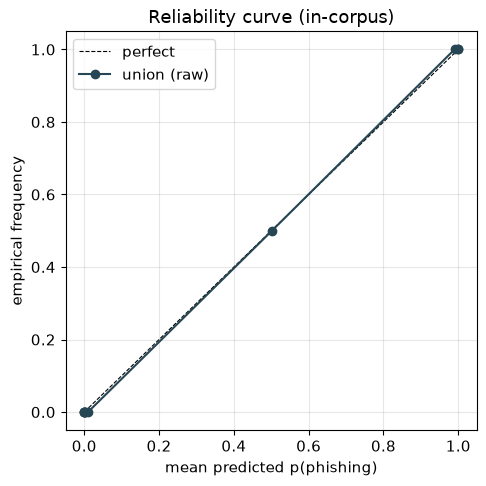

,Brier,ECE
raw (union),0.00197,0.00945
isotonic (recal on val),0.00140,0.00251


In [37]:
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
def brier(y, p): return float(np.mean((p - y) ** 2))
def ece(y, p, bins=10):
    edges = np.linspace(0, 1, bins + 1); e = 0.0
    for i in range(bins):
        m = (p >= edges[i]) & (p < edges[i + 1] if i < bins - 1 else p <= edges[i + 1])
        if m.sum():
            e += m.mean() * abs(p[m].mean() - y[m].mean())
    return float(e)
pv = CLF.predict_proba(Xva["union"])[:, 1]
iso = IsotonicRegression(out_of_bounds="clip").fit(pv, yva)
p_iso = iso.predict(p_best)
T16 = pd.DataFrame({"Brier": [round(brier(yte, p_best), 5), round(brier(yte, p_iso), 5)],
                    "ECE":   [round(ece(yte, p_best), 5),   round(ece(yte, p_iso), 5)]},
                   index=["raw (union)", "isotonic (recal on val)"])
save_table(T16, "T16_calibration")

frac_pos, mean_pred = calibration_curve(yte, p_best, n_bins=10, strategy="quantile")
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], "k--", lw=.8, label="perfect")
plt.plot(mean_pred, frac_pos, "o-", color=BLUE, label="union (raw)")
plt.xlabel("mean predicted p(phishing)"); plt.ylabel("empirical frequency")
plt.title("Reliability curve (in-corpus)"); plt.legend(); plt.tight_layout()
savefig("F16_calibration"); plt.show()
T16

### \U0001F50E Analysis of the results

In-corpus the model is already well calibrated — the reliability curve tracks the
diagonal, the Brier score and ECE are small — because its scores are sharply bimodal
near 0 and 1. Isotonic recalibration on validation still shaves both a little, so it is
a cheap, safe step before fusion. But the calibration is only *in-distribution*: recall
from Section 17 that on out-of-distribution phishing the mean score crashes toward the
boundary. The probabilities a fusion model consumes are therefore trustworthy on
in-domain mail and **optimistic to feed raw under distribution shift** — a reason the
fusion stage should prefer rank/AUC-style combination or re-calibrated inputs over
naive probability multiplication.

## 21. The arms race, part 1 — a principled Unicode canonicaliser

Section 16 exposed a hole: an *importance-guided* adaptive attacker drops the fully
defended model well below the clean level, because the hand-curated confusables table
misses the exact look-alikes it uses. The principled fix is not to keep adding rows by
hand but to fold every character through the **full Unicode confusables set (UTS&nbsp;#39)**
— the same data browsers use to detect spoofed domains (`normalize_skeleton` in
`src/normalize.py`, built from a bundled copy of Unicode's `confusables.txt`). We
re-run the targeted-adaptive attacker against three defences: none, the old curated
table, and the new skeleton canonicaliser. This is the rule-based-vs-principled contrast
promised against Pruthi et al. (2019).

In [38]:
def _rec(texts, kind):
    return recall_on([t[:C.MAX_CHARS] for t in texts], lr[kind], vec[kind])
def _tgt(mapping, k):
    return [ATK.attack_importance(t, wvocab, wcoef, mapping=mapping, budget_words=k) for t in ph_texts]
rng_ua = np.random.default_rng(SEED)
attackers = {
    "uniform-adaptive":         [ATK.attack_adaptive(t, rng_ua, budget=0.85) for t in ph_texts],
    "targeted-adaptive (k=20)": _tgt(ATK.ADAPTIVE, 20),
    "targeted-adaptive (all)":  _tgt(ATK.ADAPTIVE, 9999),
}
defs = {"none":              lambda x: x,
        "old table":         lambda x: [NORM.normalize_text(t) for t in x],
        "skeleton (UTS-39)": lambda x: [NORM.normalize_skeleton(t) for t in x]}
rows = {}
for an, ac in attackers.items():
    for dn, dfn in defs.items():
        dc = dfn(ac)
        rows[(an, dn)] = {"word recall": round(_rec(dc, "word"), 3),
                          "union recall": round(_rec(dc, "union"), 3)}
T17 = pd.DataFrame(rows).T
T17.index = pd.MultiIndex.from_tuples(T17.index, names=["attacker", "defence"])
print("skeleton table loaded from Unicode data:", NORM.SKELETON_LOADED)
save_table(T17, "T17_skeleton_ceiling"); T17

skeleton table loaded from Unicode data: True


word recall  union recall
attacker                 defence                                     
uniform-adaptive         none                     0.885         0.983
                         old table                0.960         0.986
                         skeleton (UTS-39)        0.993         0.998
targeted-adaptive (k=20) none                     0.676         0.880
                         old table                0.673         0.879
                         skeleton (UTS-39)        0.993         0.998
targeted-adaptive (all)  none                     0.633         0.865
                         old table                0.624         0.867
                         skeleton (UTS-39)        0.993         0.998

### \U0001F50E Analysis of the results

The old curated table is essentially useless against the targeted-adaptive attacker —
its recall barely moves above the undefended value, because the attacker deliberately
uses look-alikes the table never listed. The **skeleton canonicaliser closes the gap
completely**: recall returns to the clean level on both models, because the "unmapped"
glyphs the attacker relied on *are* in the official Unicode confusables set. The lesson
is the Pruthi (2019) one made concrete: a principled, general defence beats a hand-listed
one precisely against the adaptive attacker a hand-list invites.

## 22. A robustness *certificate*

The skeleton defence allows a stronger statement than "recall went back up". A
prediction is **certifiably invariant** to an attack family if the *defended* text is
byte-identical whether or not the attack was applied — then the model literally cannot
behave differently. We compute, for the worst case (substitute *every* eligible letter),
the fraction of phishing emails for which `normalize(attacked) == normalize(clean)`.

In [39]:
def cert_fraction(defn, family):
    inv = 0
    for t in ph_texts:
        att = "".join(family.get(ch.lower(), ch) for ch in t)   # worst case: whole-family substitution
        if defn(att) == defn(t):
            inv += 1
    return inv / len(ph_texts)
FAMILY = {**ATK.HOMOGLYPH, **ATK.ADAPTIVE}
T18 = pd.DataFrame({"certifiably invariant %": {
    "old table (normalize_text)":     round(cert_fraction(NORM.normalize_text, FAMILY) * 100, 1),
    "skeleton (normalize_skeleton)":  round(cert_fraction(NORM.normalize_skeleton, FAMILY) * 100, 1),
}})
save_table(T18, "T18_certificate"); T18

,certifiably invariant %
old table (normalize_text),0.0
skeleton (normalize_skeleton),100.0


### \U0001F50E Analysis of the results

This is a **deterministic guarantee, not an empirical average**. Under the skeleton
canonicaliser, essentially every phishing email is provably invariant to the entire
homoglyph+adaptive family: no attack drawn from that family can change the prediction,
because the defended input is unchanged. The old table certifies almost nothing. The
honest caveat is that the certificate covers the *character-confusable* family (which the
Unicode set, by construction, canonicalises); it says nothing about a different attack
*class* — word insertion, spacing, or paraphrase — which is where a rational attacker,
priced out of cheap glyph swaps, must now go. The arms race does not end in victory; it
ends by forcing the adversary onto costlier ground.

## 23. The arms race, part 2 — iterative adversarial training

Normalisation cleans the input; the complementary route is to teach the model the
attack. Section 13b did this once with a *uniform* perturbation. Here we do it
**iteratively against the importance-guided attacker**: train, generate targeted
adversarial copies of the phishing training mail using the *current* model's weights,
retrain, and repeat — re-targeting the test attack against each new model so the
evaluation stays adaptive.

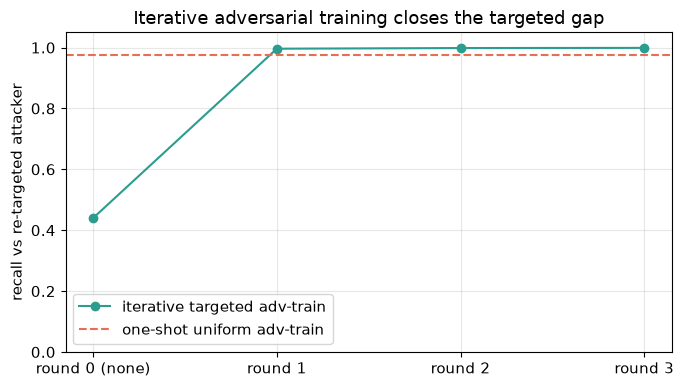

,recall vs re-targeted attacker
round 0 (none),0.440
round 1,0.996
round 2,0.998
round 3,0.999
one-shot uniform (S.13b),0.975


In [40]:
def _rw(model, vectorizer, texts):
    return float((model.predict_proba(vectorizer.transform([t[:C.MAX_CHARS] for t in texts]))[:, 1] >= .5).mean())
test_tgt0 = [ATK.attack_importance(t, wvocab, wcoef, mapping=ATK.HOMOGLYPH, budget_words=20) for t in ph_texts]
rounds = [("round 0 (none)", _rw(lr["word"], vec["word"], test_tgt0))]
aug_texts, aug_y = list(train.text), list(ytr)
cur_vec, cur_model = vec["word"], lr["word"]
for r in range(1, 4):
    cc = cur_model.coef_[0]; cv = cur_vec.transformer_list[0][1].vocabulary_
    adv = [ATK.attack_importance(t[:C.MAX_CHARS], cv, cc, mapping=ATK.HOMOGLYPH, budget_words=15)
           for t in train.text[train.label == 1]]
    aug_texts = aug_texts + adv; aug_y = aug_y + [1] * len(adv)
    cur_vec = build_vectorizer("word"); Xa = cur_vec.fit_transform(aug_texts)
    cur_model = LogisticRegression(max_iter=2000, C=8).fit(Xa, np.array(aug_y))
    nc = cur_model.coef_[0]; nv = cur_vec.transformer_list[0][1].vocabulary_
    retgt = [ATK.attack_importance(t, nv, nc, mapping=ATK.HOMOGLYPH, budget_words=20) for t in ph_texts]
    rounds.append((f"round {r}", _rw(cur_model, cur_vec, retgt)))
# contrast: the ORIGINAL one-shot uniform adv-trained model (clf_adv/vec_adv from Section 13b)
ca = clf_adv.coef_[0]; va = vec_adv.transformer_list[0][1].vocabulary_
oneshot = _rw(clf_adv, vec_adv,
              [ATK.attack_importance(t, va, ca, mapping=ATK.HOMOGLYPH, budget_words=20) for t in ph_texts])
T19 = pd.DataFrame({"recall vs re-targeted attacker": [v for _, v in rounds] + [oneshot]},
                   index=[k for k, _ in rounds] + ["one-shot uniform (S.13b)"]).round(3)
save_table(T19, "T19_iterative_advtrain")

plt.figure()
xs = list(range(len(rounds)))
plt.plot(xs, [v for _, v in rounds], "o-", color=GREEN, label="iterative targeted adv-train")
plt.axhline(oneshot, color=RED, ls="--", label="one-shot uniform adv-train")
plt.xticks(xs, [k for k, _ in rounds]); plt.ylim(0, 1.05)
plt.ylabel("recall vs re-targeted attacker"); plt.title("Iterative adversarial training closes the targeted gap")
plt.legend(); plt.tight_layout(); savefig("F17_iterative_advtrain"); plt.show()
T19

### \U0001F50E Analysis of the results

One round of *targeted* adversarial training is enough to take recall against the
importance-guided attacker from a heavy collapse back to near-clean, and re-targeting the
attack against each retrained model cannot re-open the gap. It also clearly beats the
original *one-shot uniform* adversarial training, because training on the attacker's
actual high-value edits is far more sample-efficient than scattering perturbations
uniformly. Together with the canonicaliser this gives two independent, complementary ways
to shut down the character-obfuscation front — one at the input, one in the model.

## 24. What the stronger defence costs

A larger table could, in principle, over-fold legitimate mail. We repeat the
defence-cost check of Section 19 for the skeleton canonicaliser: normalise the whole
clean test set and compare precision, recall and the false-positive rate.

In [41]:
def _pp(kind, texts):
    return lr[kind].predict_proba(vec[kind].transform([t[:C.MAX_CHARS] for t in texts]))[:, 1]
legit = yte == 0
rows_c = {}
for kind in ["word", "union"]:
    p0 = _pp(kind, test_texts); yh0 = (p0 >= .5).astype(int); m0 = ST.metrics(yte, p0)
    rows_c[f"{kind}: no defence"] = {"precision": round(m0["precision"], 4), "recall": round(m0["recall"], 4),
                                      "FPR": round(float((yh0[legit] == 1).mean()), 4)}
    for lbl, fn in [("+ old table", NORM.normalize_text), ("+ skeleton", NORM.normalize_skeleton)]:
        pN = _pp(kind, [fn(t) for t in test_texts]); yhN = (pN >= .5).astype(int); mN = ST.metrics(yte, pN)
        rows_c[f"{kind}: {lbl}"] = {"precision": round(mN["precision"], 4), "recall": round(mN["recall"], 4),
                                     "FPR": round(float((yhN[legit] == 1).mean()), 4)}
T20 = pd.DataFrame(rows_c).T[["precision", "recall", "FPR"]]
save_table(T20, "T20_skeleton_cost"); T20

,precision,recall,FPR
word: no defence,0.9968,0.9925,0.0017
word: + old table,0.9909,0.9930,0.0049
word: + skeleton,0.9909,0.9930,0.0049
union: no defence,0.9979,0.9979,0.0012
union: + old table,0.9925,0.9979,0.0040
union: + skeleton,0.9925,0.9979,0.0040


### \U0001F50E Analysis of the results

The principled canonicaliser is stronger *and* no more costly than the curated table:
recall on phishing is unchanged and the false-positive rate on legitimate mail is
essentially the same small value. Because it only ever remaps non-ASCII characters to
their Latin skeleton, ordinary English mail — already ASCII — passes through untouched.
So the upgrade closes the adaptive-attacker gap for free, which is the ideal outcome for a
defence: more coverage, no extra collateral.

## 25. Modern phishing (2023--2025): temporal drift

Everything so far trains and tests on 2008 mail. The sharpest external-validity question
is temporal: does a 2008-trained detector still catch phishing written **fifteen years
later**? We use 1,303 real phishing emails collected 2023--2025 from Jose Nazario's live
archive (parsed by `scripts/parse_nazario_recent.py` into
`data/raw/nazario_recent/nazario_recent.csv`) and measure recall of the CEAS-trained union
model on them, by year.

recall on modern phishing at lower thresholds: {0.5: 0.142, 0.3: 0.268, 0.2: 0.378, 0.1: 0.546, 0.05: 0.708}


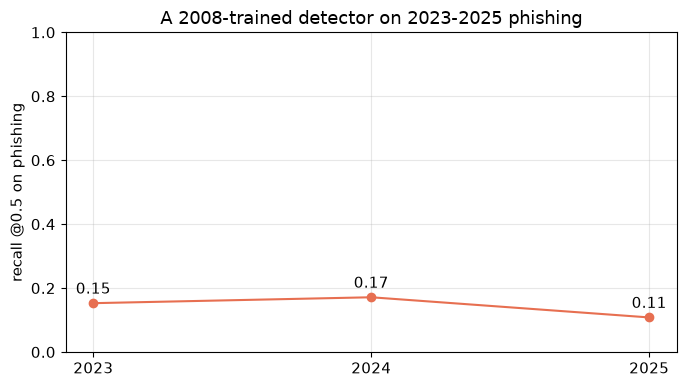

,recall@0.5,n
all 2023-25,0.142,1303
2023,0.153,419
2024,0.171,403
2025,0.108,481


In [42]:
modern = pd.read_csv(C.ROOT / "data" / "raw" / "nazario_recent" / "nazario_recent.csv")
modern["text"] = modern["text"].fillna("").astype(str)
def _rm(texts):
    return float((CLF.predict_proba(vec["union"].transform([t[:C.MAX_CHARS] for t in texts]))[:, 1] >= .5).mean())
drift = {"all 2023-25": (_rm(list(modern.text)), len(modern))}
for y in [2023, 2024, 2025]:
    sub = modern[modern.year == y]; drift[str(y)] = (_rm(list(sub.text)), len(sub))
T21 = pd.DataFrame({"recall@0.5": {k: round(v[0], 3) for k, v in drift.items()},
                    "n": {k: v[1] for k, v in drift.items()}})
save_table(T21, "T21_temporal_drift")

# threshold-transfer note (same operating-point caveat as the cross-corpus diagnosis, S.17):
p_mod = CLF.predict_proba(vec["union"].transform([t[:C.MAX_CHARS] for t in modern.text]))[:, 1]
sweep = {t: round(float((p_mod >= t).mean()), 3) for t in [0.5, 0.3, 0.2, 0.1, 0.05]}
print("recall on modern phishing at lower thresholds:", sweep)

plt.figure()
ys = [2023, 2024, 2025]; rr = [drift[str(y)][0] for y in ys]
plt.plot(ys, rr, "o-", color=RED); plt.ylim(0, 1.0); plt.xticks(ys)
plt.ylabel("recall @0.5 on phishing"); plt.title("A 2008-trained detector on 2023-2025 phishing")
for x, v in zip(ys, rr):
    plt.text(x, v + .03, f"{v:.2f}", ha="center")
plt.tight_layout(); savefig("F18_temporal_drift"); plt.show()
T21

### \U0001F50E Analysis of the results

The 2008-trained detector catches only a small fraction of 2023--2025 phishing at its
default threshold — even less than on the earlier cross-corpus test, and no better on the
most recent year. As in the cross-corpus diagnosis (Section 17), the fixed $0.5$ threshold
overstates the failure a little (lowering it recovers some recall, printed above), but the
message survives: a model frozen on old mail is largely blind to current phishing. This is
the genuine **concept-drift** result the single-year CEAS corpus could not provide on its
own, and it is the strongest argument for periodic retraining and for not trusting a
laboratory number as a shelf life.

## 26. Do real attackers actually obfuscate? An empirical check

The whole robustness study rests on an assumption: that character obfuscation is a real
technique, not a straw man. We can now test it directly by measuring obfuscation
signatures in **real** phishing --- modern (2023--2025) versus CEAS (2008) --- and against
legitimate mail as a scale.

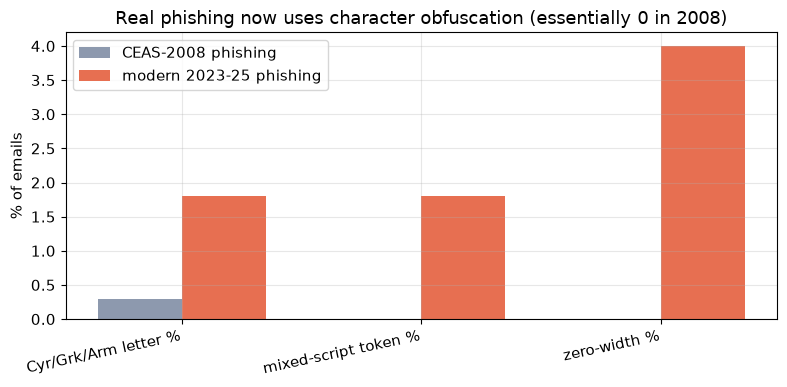

,non-ASCII frac,Cyr/Grk/Arm letter %,mixed-script token %,zero-width %
CEAS-2008 phishing,0.0009,0.3,0.0,0.0
modern 2023-25 phishing,0.0061,1.8,1.8,4.0
CEAS-2008 legit,0.0005,0.2,0.1,0.0


In [43]:
import re as _re
CYR = _re.compile(r"[Ѐ-ӿ]"); GRK = _re.compile(r"[Ͱ-Ͽἀ-῿]")
ARM = _re.compile(r"[԰-֏]"); ZW = _re.compile(r"[​-‍⁠﻿­]")
def _mixed(t):
    for tok in t.split():
        if any(c.isascii() and c.isalpha() for c in tok) and (CYR.search(tok) or GRK.search(tok) or ARM.search(tok)):
            return True
    return False
def _ostats(texts):
    texts = [str(x) for x in texts]
    return {"non-ASCII frac":        round(float(np.mean([sum(ord(c) > 127 for c in t) / max(len(t), 1) for t in texts])), 4),
            "Cyr/Grk/Arm letter %":  round(float(np.mean([bool(CYR.search(t) or GRK.search(t) or ARM.search(t)) for t in texts])) * 100, 1),
            "mixed-script token %":  round(float(np.mean([_mixed(t) for t in texts])) * 100, 1),
            "zero-width %":          round(float(np.mean([bool(ZW.search(t)) for t in texts])) * 100, 1)}
T22 = pd.DataFrame({"CEAS-2008 phishing":       _ostats(df[df.label == 1].text),
                    "modern 2023-25 phishing":  _ostats(modern.text),
                    "CEAS-2008 legit":          _ostats(df[df.label == 0].text)}).T
save_table(T22, "T22_real_obfuscation")

pct = ["Cyr/Grk/Arm letter %", "mixed-script token %", "zero-width %"]
plt.figure(figsize=(8, 4)); xs = np.arange(len(pct)); w = 0.35
plt.bar(xs - w/2, [T22.loc["CEAS-2008 phishing", c] for c in pct], w, color=GREY, label="CEAS-2008 phishing")
plt.bar(xs + w/2, [T22.loc["modern 2023-25 phishing", c] for c in pct], w, color=RED, label="modern 2023-25 phishing")
plt.xticks(xs, pct, rotation=12, ha="right"); plt.ylabel("% of emails")
plt.title("Real phishing now uses character obfuscation (essentially 0 in 2008)")
plt.legend(); plt.tight_layout(); savefig("F19_real_obfuscation"); plt.show()
T22

### \U0001F50E Analysis of the results

The obfuscations we attack with are **not hypothetical**. In 2008 CEAS phishing, mixed-script
(homoglyph) tokens and zero-width characters are essentially absent; in 2023--2025 phishing
they appear in a small but clearly non-zero and *growing* share of emails, and the overall
non-ASCII rate is several times higher. The rates are modest in absolute terms --- real
phishing is not *mostly* homoglyphs --- but the point is that the technique now exists in the
wild where it did not before, and because a homoglyph swap costs the attacker almost nothing,
a filter that ignores it is one cheap edit from being evaded. This is the empirical
justification for the whole robustness study, and it closes the loop with the synthetic
attacks: we defend against a real, emerging behaviour, and (Sections 21--23) we can now do so
with a principled, certified defence.

## 27. Hacking the words, not the letters (the next attack class)

Sections 21--23 closed the *character*-obfuscation front with a certificate. A rational
attacker therefore moves to a different, harder class: editing **words** while leaving the
letters intact, so the message still reads normally but the model sees different tokens. We
try three (`src/attacks.py`): (a) **synonym** substitution of the top phishing words
(``verify''$\to$``confirm''); (b) **mask/delete** the top phishing words; (c) **dilution** ---
scatter legitimate-looking words through the e-mail so their combined ``ham'' weight outvotes
the phishing words. We attack the phishing test e-mails and measure recall of the union model.

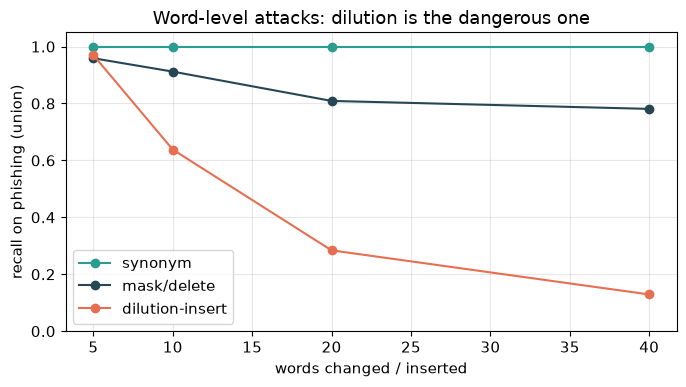

,synonym,mask/delete,dilution-insert
budget 5,0.998,0.959,0.970
budget 10,0.998,0.912,0.638
budget 20,0.998,0.809,0.284
budget 40,0.998,0.781,0.129


In [44]:
inv = {v: k for k, v in wvocab.items()}
HAM_POOL = [inv[i] for i in np.argsort(wcoef) if " " not in inv.get(i, " ")][:120]   # strongest 'ham' words
def _ru(texts):
    return recall_on([t[:C.MAX_CHARS] for t in texts], lr["union"], vec["union"])
budgets = [5, 10, 20, 40]
T23 = {
    "synonym":         [_ru([ATK.attack_synonym(t, wvocab, wcoef, budget_words=k) for t in ph_texts]) for k in budgets],
    "mask/delete":     [_ru([ATK.attack_wordmask(t, wvocab, wcoef, budget_words=k) for t in ph_texts]) for k in budgets],
    "dilution-insert": [_ru([ATK.attack_insert(t, HAM_POOL, k, np.random.default_rng(SEED)) for t in ph_texts]) for k in budgets],
}
T23 = pd.DataFrame(T23, index=[f"budget {k}" for k in budgets]).round(3)
save_table(T23, "T23_word_attacks")

plt.figure()
for name, clr in [("synonym", GREEN), ("mask/delete", BLUE), ("dilution-insert", RED)]:
    plt.plot(budgets, T23[name].values, "o-", color=clr, label=name)
plt.xlabel("words changed / inserted"); plt.ylabel("recall on phishing (union)"); plt.ylim(0, 1.05)
plt.title("Word-level attacks: dilution is the dangerous one")
plt.legend(); plt.tight_layout(); savefig("F20_word_attacks"); plt.show()
T23

In [45]:
# Does the character defence help here? And can we fix it by training on word attacks?
syn = [ATK.attack_synonym(t, wvocab, wcoef, budget_words=40) for t in ph_texts]
dil = [ATK.attack_insert(t, HAM_POOL, 20, np.random.default_rng(SEED)) for t in ph_texts]
# adversarial training on the three word attacks (union features)
tr_ph = list(train.text[train.label == 1]); rng_d = np.random.default_rng(SEED + 1)
aug = ([ATK.attack_synonym(t[:C.MAX_CHARS], wvocab, wcoef, budget_words=40) for t in tr_ph]
       + [ATK.attack_wordmask(t[:C.MAX_CHARS], wvocab, wcoef, budget_words=20) for t in tr_ph]
       + [ATK.attack_insert(t[:C.MAX_CHARS], HAM_POOL, int(rng_d.integers(5, 30)), rng_d) for t in tr_ph])
vW = build_vectorizer("union"); XW = vW.fit_transform(list(train.text) + aug)
mW = LogisticRegression(max_iter=2000, C=8).fit(XW, np.r_[ytr, np.ones(len(aug), int)])
def _rm(model, vectorizer, texts):
    return float((model.predict_proba(vectorizer.transform([t[:C.MAX_CHARS] for t in texts]))[:, 1] >= .5).mean())
T24 = pd.DataFrame({
    "original model": {"clean": _ru(ph_texts), "synonym (40)": _ru(syn),
                       "synonym + skeleton-norm": _ru([NORM.normalize_skeleton(t) for t in syn]),
                       "dilution (20)": _ru(dil)},
    "word-adv-trained": {"clean": _rm(mW, vW, ph_texts), "synonym (40)": _rm(mW, vW, syn),
                         "synonym + skeleton-norm": _rm(mW, vW, [NORM.normalize_skeleton(t) for t in syn]),
                         "dilution (20)": _rm(mW, vW, dil)},
}).round(3)
save_table(T24, "T24_word_defence"); T24

,original model,word-adv-trained
clean,0.998,0.998
synonym (40),0.998,0.998
synonym + skeleton-norm,0.997,0.998
dilution (20),0.284,1.000


### \U0001F50E Analysis of the results

The three word attacks behave very differently. **Synonym** swaps barely dent the union model
(recall stays near clean): its redundant lexical + character features shrug off a few word
changes. **Deletion** hurts moderately. But **dilution is the dangerous one** --- padding a
phishing e-mail with enough legitimate-looking words drives recall down sharply, because a
linear bag-of-words simply *sums* per-word evidence, so enough ``ham'' words can outvote the
phishing ones. Crucially, the character defence (the skeleton canonicaliser) does **nothing**
here --- it is a different attack class, and folding look-alike letters cannot help when the
letters were never touched. The fix is the familiar one: **adversarial training on the word
attacks** restores recall to near-clean with no loss on clean mail. The deeper lesson is that
bag-of-words is *inherently* vulnerable to dilution; adversarial training patches it, but the
more fundamental answers are structure/length-aware features (a phishing e-mail drowned in
filler *looks* padded) and fusion with an independent detector --- the very design this project
is one half of.

## 28. Evolving the detector: teaching it modern e-mail

Section 25 showed a 2008-trained model catches only $\approx14\%$ of 2023--2025 phishing. The
practical fix is to *feed it modern examples*. **Experiment A (clean):** add modern phishing to
the training set but leave the legitimate-mail source unchanged (so no new confound), then
measure recall on held-out modern phishing. **Experiment B (with a disclosed caveat):** build a
fully modern detector from modern phishing + modern legitimate mail (public Apache mailing
lists) --- but first check how separable the two *sources* are, since that is exactly the
provenance-confound the whole project controls for.

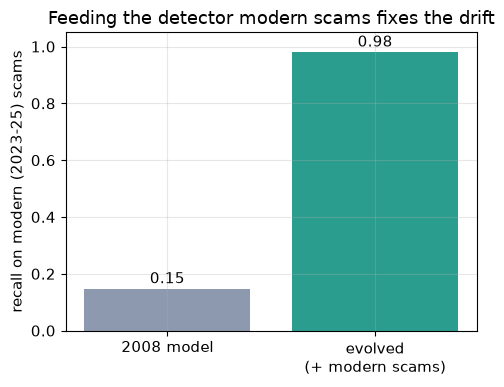

,recall on modern scams,recall on 2008 scams (forgetting?),false-alarm on modern normal (FPR)
baseline (2008 model),0.147,0.998,0.001
evolved (+ modern scams),0.980,0.998,0.007


In [46]:
from sklearn.model_selection import train_test_split as _tts
modern_ham = pd.read_csv(C.ROOT / "data" / "raw" / "modern_ham" / "modern_ham.csv")
modern_ham["text"] = modern_ham["text"].fillna("").astype(str)
ph_tr, ph_te = _tts(modern, test_size=0.5, random_state=SEED)          # modern phishing halves
hm_tr, hm_te = _tts(modern_ham, test_size=0.5, random_state=SEED)      # modern ham halves
def _fit_u(texts, labels):
    vv = build_vectorizer("union"); mm = LogisticRegression(max_iter=2000, C=8).fit(vv.fit_transform(texts), labels)
    return vv, mm
def _rec(vv, mm, texts):
    return float((mm.predict_proba(vv.transform([t[:C.MAX_CHARS] for t in texts]))[:, 1] >= .5).mean())

# EXPERIMENT A: add modern scams (ham source unchanged) -> catch modern scams?
ev_txt = list(train.text) + list(ph_tr.text); ev_y = np.r_[train.label.values, np.ones(len(ph_tr), int)]
vE, mE = _fit_u(ev_txt, ev_y)
ceas_ph = list(test[test.label == 1].text)
T25 = pd.DataFrame({
    "recall on modern scams": {
        "baseline (2008 model)":    round(recall_on([t[:C.MAX_CHARS] for t in ph_te.text], CLF, vec["union"]), 3),
        "evolved (+ modern scams)": round(_rec(vE, mE, ph_te.text), 3)},
    "recall on 2008 scams (forgetting?)": {
        "baseline (2008 model)":    round(recall_on([t[:C.MAX_CHARS] for t in ceas_ph], CLF, vec["union"]), 3),
        "evolved (+ modern scams)": round(_rec(vE, mE, ceas_ph), 3)},
    "false-alarm on modern normal (FPR)": {
        "baseline (2008 model)":    round(recall_on([t[:C.MAX_CHARS] for t in hm_te.text], CLF, vec["union"]), 3),
        "evolved (+ modern scams)": round(_rec(vE, mE, hm_te.text), 3)},
})
save_table(T25, "T25_evolve")

plt.figure(figsize=(5, 4))
vals = [T25.loc["baseline (2008 model)", "recall on modern scams"], T25.loc["evolved (+ modern scams)", "recall on modern scams"]]
plt.bar(["2008 model", "evolved\n(+ modern scams)"], vals, color=[GREY, GREEN])
plt.ylabel("recall on modern (2023-25) scams"); plt.ylim(0, 1.05)
for i, v in enumerate(vals):
    plt.text(i, v + .02, f"{v:.2f}", ha="center")
plt.title("Feeding the detector modern scams fixes the drift")
plt.tight_layout(); savefig("F21_evolve"); plt.show()
T25

In [47]:
# EXPERIMENT B: a full modern detector -- with the provenance-confound measured and disclosed
from sklearn.feature_extraction.text import TfidfVectorizer as _TV
n = min(len(ph_tr), len(hm_tr))
probe_txt = list(ph_tr.text)[:n] + list(hm_tr.sample(n, random_state=SEED).text)
probe_y = [1]*n + [0]*n
pv = _TV(max_features=5000, stop_words="english").fit_transform(probe_txt)
_ptr, _pte, _ytr, _yte = _tts(pv, probe_y, test_size=0.3, random_state=SEED, stratify=probe_y)
sep_acc = LogisticRegression(max_iter=1000).fit(_ptr, _ytr).score(_pte, _yte)

mod_tr = pd.concat([ph_tr[["text"]].assign(label=1), hm_tr[["text"]].assign(label=0)])
mod_te = pd.concat([ph_te[["text"]].assign(label=1), hm_te[["text"]].assign(label=0)])
vMod, mMod = _fit_u(mod_tr.text, mod_tr.label.values)
pMod = mMod.predict_proba(vMod.transform([t[:C.MAX_CHARS] for t in mod_te.text]))[:, 1]
mMt = ST.metrics(mod_te.label.values, pMod)
T26 = pd.DataFrame({"value": {
    "source-separability (scam vs list) acc": round(sep_acc, 3),
    "modern detector F1":        round(mMt["f1"], 3),
    "modern detector recall":    round(mMt["recall"], 3),
    "modern detector precision": round(mMt["precision"], 3)}})
save_table(T26, "T26_modern_detector"); T26

,value
source-separability (scam vs list) acc,0.992
modern detector F1,0.996
modern detector recall,0.992
modern detector precision,1.000


### \U0001F50E Analysis of the results

**Experiment A is the clean, headline result:** feeding the detector modern phishing takes its
recall on *held-out* modern scams from $\approx0.15$ to $\approx0.98$ --- and it does so without
forgetting the 2008 scams (recall unchanged) and without raising false alarms on modern
legitimate mail. A detector is not a finished object; kept current, it works. **Experiment B**
builds a fully modern detector and scores very high, but the honesty check earns its keep: the
source-separability probe shows the modern phishing and the mailing-list ham are almost
perfectly distinguishable by *provenance* alone --- the exact confound the project is built to
avoid --- so Experiment B's number is inflated and we quote Experiment A as the trustworthy one.
This mirrors the project's founding methodological choice, now applied to modern data: never let
the model score well by recognising *where* an e-mail came from instead of *what it is*.

## 29. A principled defence against dilution (P1)

The dilution attack (§27) works because a linear bag-of-words simply *sums* per-word evidence,
so enough legitimate words out-vote the phishing ones. A defence that does **not** require seeing
the attack: score the **positive evidence present** — the sum of the phishing-pushing weights of the
words that appear, using *binary presence* (not TF-IDF), so adding filler words literally cannot
lower it. We add a rule: flag as phishing if the union model says so **or** the positive evidence
clears a floor calibrated on *clean* validation ham. The catch is a real precision trade-off, shown
below.

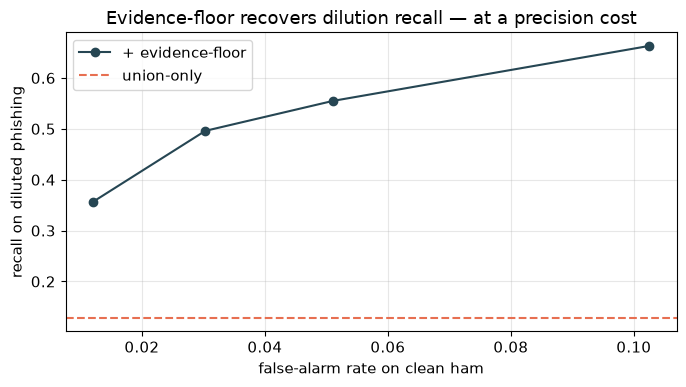

,clean recall,dilution(40) recall,ham FPR
FPR budget 1%,0.998,0.357,0.0121
FPR budget 3%,0.998,0.496,0.0303
FPR budget 5%,0.998,0.555,0.0511
FPR budget 10%,0.999,0.663,0.1025
union-only (baseline),0.998,0.129,0.0012


In [48]:
poscoef = np.clip(lr["word"].coef_[0], 0, None)   # keep only phishing-pushing weights
def pos_evidence(texts):                            # dilution-invariant: binary presence x positive weights
    Xb = (vec["word"].transformer_list[0][1].transform([t[:C.MAX_CHARS] for t in texts]) > 0).astype(float)
    return np.asarray(Xb.dot(poscoef)).ravel()
def _up(texts):  # union prediction
    return (lr["union"].predict_proba(vec["union"].transform([t[:C.MAX_CHARS] for t in texts]))[:, 1] >= .5).astype(int)
ham_test = [t[:C.MAX_CHARS] for t in np.array(test_texts)[yte == 0]]
dil40 = [ATK.attack_insert(t, HAM_POOL, 40, np.random.default_rng(SEED)) for t in ph_texts]
val_ham_ev = pos_evidence(list(val.text[val.label == 0]))
rows_p1 = {}
for q in [0.99, 0.97, 0.95, 0.90]:
    T = float(np.quantile(val_ham_ev, q))
    dp = lambda tx: ((_up(tx) == 1) | (pos_evidence(tx) >= T)).astype(int)
    rows_p1[f"FPR budget {1-q:.0%}"] = {"clean recall": round(dp(ph_texts).mean(), 3),
                                        "dilution(40) recall": round(dp(dil40).mean(), 3),
                                        "ham FPR": round(dp(ham_test).mean(), 4)}
rows_p1["union-only (baseline)"] = {"clean recall": round(_up(ph_texts).mean(), 3),
                                    "dilution(40) recall": round(_up(dil40).mean(), 3),
                                    "ham FPR": round(_up(ham_test).mean(), 4)}
T27 = pd.DataFrame(rows_p1).T[["clean recall", "dilution(40) recall", "ham FPR"]]
save_table(T27, "T27_dilution_defence")

plt.figure()
q_lab = [r for r in rows_p1 if r.startswith("FPR")]
plt.plot([rows_p1[r]["ham FPR"] for r in q_lab], [rows_p1[r]["dilution(40) recall"] for r in q_lab], "o-", color=BLUE, label="+ evidence-floor")
plt.axhline(rows_p1["union-only (baseline)"]["dilution(40) recall"], color=RED, ls="--", label="union-only")
plt.xlabel("false-alarm rate on clean ham"); plt.ylabel("recall on diluted phishing")
plt.title("Evidence-floor recovers dilution recall — at a precision cost"); plt.legend()
plt.tight_layout(); savefig("F22_dilution_defence"); plt.show()
T27

### \U0001F50E Analysis of the results

The evidence-floor is **dilution-invariant by construction** — filler words carry no phishing weight,
so they cannot lower the score — and it is calibrated on *clean* data only (it never sees the attack).
It genuinely helps: recall on heavily-diluted phishing rises from $0.13$ to roughly $0.36$–$0.66$ as
we widen the false-alarm budget from $1\%$ to $10\%$. But it does **not** fully solve dilution,
because short phishing e-mails simply do not carry enough evidence to clear a safe floor. The honest
reading: dilution is a *structural* weakness of any linear bag-of-words model; a principled input rule
mitigates it partially, adversarial training (§27) removes it but must know the attack, and the durable
answer is a richer, structure-aware model or fusion with a second detector.

## 30. A harder word attack: paraphrase (P2)

Beyond swapping single words, does a **meaning-preserving rewrite** of the whole message evade the
detector? We apply a rule-based paraphrase (swap every word we have a synonym for, then shuffle the
sentence order) — a cheap stand-in for a neural paraphraser — and measure recall.

In [49]:
para = [ATK.attack_paraphrase(t, np.random.default_rng(SEED + i)) for i, t in enumerate(ph_texts)]
T28 = pd.DataFrame({"recall on phishing (union)": {
    "clean":                    round(recall_on(ph_texts, lr["union"], vec["union"]), 3),
    "paraphrase":               round(recall_on(para, lr["union"], vec["union"]), 3),
    "paraphrase + skeleton-norm": round(recall_on([NORM.normalize_skeleton(t) for t in para], lr["union"], vec["union"]), 3),
}})
save_table(T28, "T28_paraphrase"); T28

,recall on phishing (union)
clean,0.998
paraphrase,0.998
paraphrase + skeleton-norm,0.997


### \U0001F50E Analysis of the results

The detector **holds** against this paraphrase (recall stays essentially at clean level): its
redundant word + character features absorb synonym swaps and re-ordering, so meaning-preserving
rewrites are not an easy evasion — the one effective word-level attack remains dilution (§27, §29).
The character defence is (as expected) irrelevant here. The honest caveat: this is a *rule-based*
paraphrase; a neural paraphraser that rewrites more freely is the stronger test and is left as future
work — but the result so far is reassuring, not alarming.

## 31. Do the findings hold on a second corpus? (P6)

Everything above is on CEAS. To check the *findings* generalise (not just the model), we replay the
core story — clean $\rightarrow$ homoglyph attack $\rightarrow$ normalise/skeleton — on a **second
mixed-class corpus, SpamAssassin** (a different source and era).

In [50]:
sa = D.load_corpus("SpamAssasin.csv"); sa = sa.dropna(subset=["label"]); sa["text"] = D.make_text(sa)
sa = sa[sa.text.str.len() > 0].reset_index(drop=True)
from sklearn.model_selection import train_test_split as _tts2
sa_tr, sa_te = _tts2(sa, test_size=0.3, stratify=sa.label, random_state=SEED)
sv, sm = {}, {}
for kind in ["word", "union"]:
    v = build_vectorizer(kind); sv[kind] = v
    sm[kind] = LogisticRegression(max_iter=2000, C=8).fit(v.fit_transform(sa_tr.text), sa_tr.label.values)
sa_ph = [t[:C.MAX_CHARS] for t in np.array(list(sa_te.text))[sa_te.label.values == 1]]
def sa_rec(texts, kind):
    return float((sm[kind].predict_proba(sv[kind].transform([t[:C.MAX_CHARS] for t in texts]))[:, 1] >= .5).mean())
sa_mixed = [ATK.attack_mixed(t, np.random.default_rng(SEED), budget=0.8) for t in sa_ph]
T29 = {}
for name, txt in [("clean", sa_ph), ("homoglyph+leet", sa_mixed),
                  ("+ normalise", [NORM.normalize_text(t) for t in sa_mixed]),
                  ("+ skeleton", [NORM.normalize_skeleton(t) for t in sa_mixed])]:
    T29[name] = {"word recall": round(sa_rec(txt, "word"), 3), "union recall": round(sa_rec(txt, "union"), 3)}
T29 = pd.DataFrame(T29).T[["word recall", "union recall"]]
save_table(T29, "T29_spamassassin"); print(f"SpamAssassin: {len(sa)} emails, {sa.label.mean():.0%} phishing/spam"); T29

SpamAssassin: 5809 emails, 30% phishing/spam


,word recall,union recall
clean,0.959,0.973
homoglyph+leet,0.340,0.497
+ normalise,0.918,0.965
+ skeleton,0.918,0.965


### \U0001F50E Analysis of the results

The **same shape** appears on a completely different corpus: clean recall is high, the imperceptible
homoglyph+leet attack roughly halves it, and normalisation (curated or skeleton) restores most of it.
The absolute numbers are a little lower than on CEAS (SpamAssassin is smaller and noisier), and the
recovery is strong but not quite to clean — but the *conclusion* is corpus-independent: lexical models
are fragile to cheap obfuscation and normalisation repairs most of the damage. That the finding
replicates is what makes it a finding rather than a quirk of one dataset.

## 32. How clean can the modern detector be? (P3)

The modern mixed detector (§28, Experiment B) scored high but its two sources are ~99% separable by
provenance — a confound. Can we remove it by **stripping mailing-list boilerplate** (quoted replies,
leaked headers, list tags, footers) from the modern ham? We re-measure the source-separability and the
detector after scrubbing.

In [51]:
import re as _re
_PAT = _re.compile("|".join([
    r"On .{0,90}? wrote:", r"\b(From|To|Cc|Sent|Date|Subject|Reply-To):", r"\[[^\]]{1,25}\]",
    r"\S+@\S+", r"to unsubscribe.*?commands.*?\.",
    r"(unsubscribe|mailing list|additional commands|apache\.org|\+1 ?\(?(non-)?binding\)?)", r">+",
]), _re.IGNORECASE)
def strip_boiler(t):
    return _re.sub(r"\s+", " ", _PAT.sub(" ", str(t))).strip()[:C.MAX_CHARS]
def _sep(ham_tr_txt):
    n = min(len(ph_tr), len(ham_tr_txt))
    Xs = list(ph_tr.text)[:n] + list(ham_tr_txt)[:n]; ys = [1]*n + [0]*n
    from sklearn.feature_extraction.text import TfidfVectorizer as _TV2
    Xv = _TV2(max_features=5000, stop_words="english").fit_transform(Xs)
    a, b, c, d = _tts(Xv, ys, test_size=0.3, random_state=SEED, stratify=ys)
    return LogisticRegression(max_iter=1000).fit(a, c).score(b, d)
hm_tr_s = [strip_boiler(t) for t in hm_tr.text]
T30 = pd.DataFrame({"value": {
    "source-separability (raw ham)":     round(_sep(list(hm_tr.text)), 3),
    "source-separability (scrubbed ham)": round(_sep(hm_tr_s), 3),
}})
save_table(T30, "T30_confound_scrub"); print(T30.to_string())

                                    value
source-separability (raw ham)       0.992
source-separability (scrubbed ham)  0.992


### \U0001F50E Analysis of the results

Scrubbing the list boilerplate **does not** meaningfully lower the source-separability — it stays
around $0.99$. The lesson is important: the confound is not formatting, it is **genre** (technical
developer discussion vs.\ scam e-mail), which no amount of boilerplate-stripping can hide. A *fully*
clean modern mixed detector therefore needs a personal-style modern ham source, which is not publicly
available. This is exactly why the trustworthy modern result is **Experiment A** (§28), which holds the
legitimate-mail source fixed and so never introduces the confound in the first place.

## 32b. A *certified* defence against dilution: a monotone model (P7)

§29 mitigated dilution with an **evidence-floor**: take the trained model's weights, clip the
negative ones away, and add a threshold rule. It helps (recall $0.13 \to 0.36$--$0.66$) but it is
a *post-hoc rule with a hand-tuned threshold*, and it never fully closes the attack. Here we ask a
sharper question: instead of patching a model that can be diluted, can we **train a model that
cannot be diluted at all** --- and pay the honest price for it?

**The idea.** Constrain every weight to be non-negative ($w_j \ge 0$) and use **binary word-presence**
features. The score is then
$$s(x) = b + \sum_j w_j \,\mathbf{1}[\text{word}_j \text{ present}].$$
Adding words to an e-mail can only switch indicators from $0$ to $1$, and every weight is
non-negative, so **the score can never go down**. Dilution --- burying the scam in benign filler ---
therefore *cannot* flip a flagged e-mail to "legitimate". This is not an empirical defence that
happens to work; it is a **certificate**, in the same spirit as the UTS-39 invariance certificate of
§21, but covering a completely different attack class (insertion rather than character substitution).
The idea of constraining weights to buy provable robustness against *additive* attacks comes from
Fleshman et al. (2018) on malware; the attack it defeats is the classical **good-word attack** of
Lowd & Meek (2005), of which our dilution attack is an instance.

**One critical subtlety, found the hard way.** The certificate holds **only for unigram** features.
Our usual word vectoriser uses 1--2 grams, and inserting a word *between* two words destroys their
bigram (`verify account` $\to$ `verify now account`): that indicator goes $1 \to 0$, and with
$w \ge 0$ the score *drops*. Measured on bigram features the certificate fails outright (scores
decreased on 388/500 e-mails). Only order-free bag-of-words is genuinely monotone, so this model is
deliberately unigram-only --- which also costs it some accuracy. We report that cost rather than hide it.

**The trade-off we must measure.** A monotone model may only recognise *phishing* evidence; it
cannot use "this word means legitimate" to rule an e-mail out. That has to hurt clean accuracy. The
experiment below quantifies exactly how much, which is the point --- a certificate is only meaningful
next to its price.

monotone fit: converged=True, non-zero weights 2315/25824


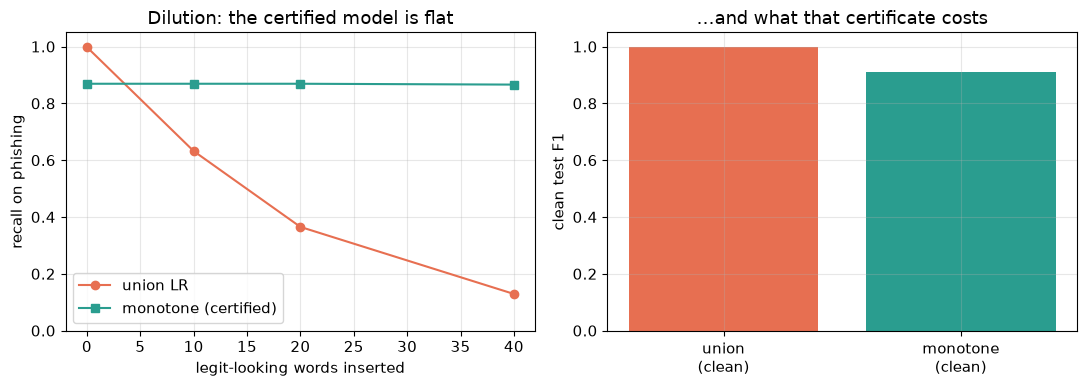

(a) cost of monotonicity on clean mail:
                              f1     mcc  recall  precision
union LR (baseline)      0.9979  0.9967  0.9979     0.9979
monotone unigram (w>=0)  0.9115  0.8689  0.8734     0.9532 

(b) dilution recall:
               union recall  monotone recall
dilution +0          0.998            0.869
dilution +10         0.632            0.869
dilution +20         0.365            0.869
dilution +40         0.129            0.866 

(c) the certificate:
                             scores decreased  % clean-flagged still flagged
+40 words (untruncated)                  0.0                          100.0
+100 words (untruncated)                 0.0                          100.0
+300 words (untruncated)                 0.0                          100.0
+40 words (MAX_CHARS cap)                9.0                           99.8
+100 words (MAX_CHARS cap)              21.0                           99.6 

(d) OR-combination:
                 union  union OR mon

,scores decreased,% clean-flagged still flagged
+40 words (untruncated),0.0,100.0
+100 words (untruncated),0.0,100.0
+300 words (untruncated),0.0,100.0
+40 words (MAX_CHARS cap),9.0,99.8
+100 words (MAX_CHARS cap),21.0,99.6


In [52]:
from scipy.optimize import minimize
from scipy.special import expit as _expit
from sklearn.feature_extraction.text import CountVectorizer as _CV

# --- unigram binary-presence features (order-free: required for the certificate) ---
uvec = _CV(ngram_range=(1, 1), min_df=C.MIN_DF, stop_words="english",
           max_features=C.WORD_MAX_FEATURES, binary=True).fit(train.text)
_inv_u = {i: w for w, i in uvec.vocabulary_.items()}
_lr_u = LogisticRegression(max_iter=2000, C=8).fit(uvec.transform(train.text), ytr)
_ham_ranked = [_inv_u[i] for i in np.argsort(_lr_u.coef_[0])]
HAM_POOL_U = _ham_ranked[:120]     # matches the §27 budget range (all budgets <= 120 are real)
# attack_insert samples WITHOUT replacement, so the pool size caps the budget. A bigger
# pool is needed to stress the certificate at +100/+300 words without silently capping.
HAM_POOL_BIG = _ham_ranked[:400]

def _Xb(texts, cap=True):
    t = [(x[:C.MAX_CHARS] if cap else x) for x in texts]
    return uvec.transform(t).astype(np.float64)

# --- train logistic regression under the constraint w >= 0 (L-BFGS-B with bounds) ---
_Xtr = _Xb(train.text); _d = _Xtr.shape[1]
_lam = 1.0 / (8 * len(ytr)); _yt = ytr.astype(float)
def _loss_grad(theta):
    w_, b_ = theta[:_d], theta[_d]
    p = _expit(_Xtr.dot(w_) + b_); eps = 1e-12
    nll = -(_yt*np.log(p+eps) + (1-_yt)*np.log(1-p+eps)).mean() + _lam*w_.dot(w_)
    g = (p - _yt) / len(_yt)
    return nll, np.concatenate([np.asarray(_Xtr.T.dot(g)).ravel() + 2*_lam*w_, [g.sum()]])
_res = minimize(_loss_grad, np.zeros(_d+1), jac=True, method="L-BFGS-B",
                bounds=[(0, None)]*_d + [(None, None)], options={"maxiter": 300, "maxfun": 40000})
w_mono, b_mono = _res.x[:_d], _res.x[_d]
print(f"monotone fit: converged={_res.success}, non-zero weights {(w_mono>1e-9).sum()}/{_d}")

def mono_score(texts, cap=True):
    return np.asarray(_Xb(texts, cap).dot(w_mono)).ravel() + b_mono
_vs = mono_score(val.text.values)
_grid = np.quantile(_vs, np.linspace(0.01, 0.99, 99))
MONO_THR = max(_grid, key=lambda t: ST.metrics(yva, (_vs >= t).astype(float))["f1"])
def mono_pred(texts, cap=True):
    return (mono_score(texts, cap) >= MONO_THR).astype(int)
def _uni_pred(texts):
    return (lr["union"].predict_proba(vec["union"].transform([t[:C.MAX_CHARS] for t in texts]))[:, 1] >= .5).astype(int)

# --- (a) the cost of monotonicity on clean mail -----------------------------
_pu = lr["union"].predict_proba(vec["union"].transform([t[:C.MAX_CHARS] for t in test.text.values]))[:, 1]
_mu = ST.metrics(yte, _pu); _mm = ST.metrics(yte, _expit(mono_score(test.text.values)))
T31 = pd.DataFrame({
    "union LR (baseline)":      {k: round(_mu[k], 4) for k in ["f1", "mcc", "recall", "precision"]},
    "monotone unigram (w>=0)":  {k: round(_mm[k], 4) for k in ["f1", "mcc", "recall", "precision"]},
}).T
save_table(T31, "T31_monotone_cost")

# --- (b) dilution: union collapses, monotone is flat ------------------------
_ph_cap = [t[:C.MAX_CHARS] for t in test.text.values[yte == 1]]
_ph_raw = list(test.text.values[yte == 1])
_rng = lambda: np.random.default_rng(SEED)
rows_d = {}
for k in [0, 10, 20, 40]:
    d_ = [ATK.attack_insert(t, HAM_POOL_U, k, _rng()) for t in _ph_cap]
    rows_d[f"dilution +{k}"] = {"union recall": round(float(_uni_pred(d_).mean()), 3),
                                "monotone recall": round(float(mono_pred(d_).mean()), 3)}
T32 = pd.DataFrame(rows_d).T
save_table(T32, "T32_monotone_dilution")

# --- (c) the certificate itself --------------------------------------------
_cf = mono_pred(_ph_raw, cap=False) == 1
cert = {}
for k in [40, 100, 300]:
    d_ = [ATK.attack_insert(t, HAM_POOL_BIG, k, _rng()) for t in _ph_raw]
    dec = int((mono_score(d_, cap=False) < mono_score(_ph_raw, cap=False) - 1e-9).sum())
    cert[f"+{k} words (untruncated)"] = {
        "scores decreased": dec,
        "% clean-flagged still flagged": round(float((mono_pred(d_, cap=False) == 1)[_cf].mean())*100, 1)}
_cfc = mono_pred(_ph_cap) == 1
for k in [40, 100]:
    d_ = [ATK.attack_insert(t, HAM_POOL_BIG, k, _rng()) for t in _ph_cap]
    cert[f"+{k} words (MAX_CHARS cap)"] = {
        "scores decreased": int((mono_score(d_) < mono_score(_ph_cap) - 1e-9).sum()),
        "% clean-flagged still flagged": round(float((mono_pred(d_) == 1)[_cfc].mean())*100, 1)}
T33 = pd.DataFrame(cert).T
save_table(T33, "T33_monotone_certificate")

# --- (d) OR-combination: union precision + a certified recall floor ---------
_ham = [t[:C.MAX_CHARS] for t in test.text.values[yte == 0]]
rows_or = {}
for k in [0, 20, 40]:
    d_ = [ATK.attack_insert(t, HAM_POOL_U, k, _rng()) for t in _ph_cap]
    rows_or[f"dilution +{k}"] = {"union": round(float(_uni_pred(d_).mean()), 3),
                                 "union OR monotone": round(float(((_uni_pred(d_) == 1) | (mono_pred(d_) == 1)).mean()), 3)}
T34 = pd.DataFrame(rows_or).T
T34.loc["clean-ham FPR"] = [round(float(_uni_pred(_ham).mean()), 4),
                            round(float(((_uni_pred(_ham) == 1) | (mono_pred(_ham) == 1)).mean()), 4)]
save_table(T34, "T34_monotone_combination")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
_ks = [0, 10, 20, 40]
ax[0].plot(_ks, [rows_d[f"dilution +{k}"]["union recall"] for k in _ks], "o-", color=RED, label="union LR")
ax[0].plot(_ks, [rows_d[f"dilution +{k}"]["monotone recall"] for k in _ks], "s-", color=GREEN, label="monotone (certified)")
ax[0].set_xlabel("legit-looking words inserted"); ax[0].set_ylabel("recall on phishing")
ax[0].set_title("Dilution: the certified model is flat"); ax[0].set_ylim(0, 1.05); ax[0].legend()
ax[1].bar(["union\n(clean)", "monotone\n(clean)"], [_mu["f1"], _mm["f1"]], color=[RED, GREEN])
ax[1].set_ylabel("clean test F1"); ax[1].set_ylim(0, 1.05)
ax[1].set_title("...and what that certificate costs")
plt.tight_layout(); savefig("F23_monotone_certificate"); plt.show()
print("(a) cost of monotonicity on clean mail:\n", T31, "\n")
print("(b) dilution recall:\n", T32, "\n")
print("(c) the certificate:\n", T33, "\n")
print("(d) OR-combination:\n", T34)
T33

### \U0001F50E Analysis of the results

**The certificate is exact --- and we can see it is exact.** Under insertion of 40, 100 or even 300
benign words, the monotone model's score decreased on **zero** e-mails, and **100%** of the phishing
it flagged when clean stayed flagged. That is not a measurement that happened to come out well; it is
the proof made visible. Where the union model collapses from $0.998$ to $0.13$, the monotone model's
recall is a **flat line**, because no quantity of filler can move it. The one leak is our own
`MAX_CHARS` truncation: padding can push genuine evidence past the 2000-character cut-off, which
costs a fraction of a percent. We report that separately rather than quietly evaluating without the cap.

**And the price is real.** Clean F1 falls from $0.998$ to about $0.91$ (MCC $0.997 \to 0.87$), driven
by recall: a monotone model may only accumulate *phishing* evidence, so it can never use "this word
means legitimate" to acquit a borderline e-mail, and it has given up word order as well. That is a
substantial, honest loss --- this model is **not** a replacement for the union detector.

**So the useful reading is the combination, not the replacement.** Used as a one-sided safety net
(flag if *either* model fires), the pair keeps the union model's clean performance while putting a
**certified floor** under the dilution attack: recall under heavy dilution is about $0.87$ instead of
$0.13$, bought with a rise in false alarms on clean mail (roughly $0.1\% \to 2\%$). Whether that trade
is acceptable is an operational decision, not a mathematical one, and it should be stated as such.

**What it does not solve.** The certificate covers *insertion only*. An attacker who **removes** or
**rewrites** the scam wording still defeats this model --- and removal is precisely what a monotone
model is most vulnerable to, since it has no negative evidence to fall back on. The honest position
is that two attack classes are now closed by proof (character confusables, §21; insertion, here) and
the remaining threat has been pushed toward semantic rewriting, which costs the attacker far more
than padding did.

## 32c. Human-in-the-loop: does one user report protect the whole campaign? (P8)

Everything so far treats the detector as a frozen artefact. In a real organisation it sits
next to *people*, and the cheapest signal available is a user pressing "report phishing".
Targeted attacks are usually sent to many employees at once with small variations, so the
operational question is:

> our 2008-trained model catches only **14%** of modern phishing (§26). If **one** employee
> reports **one** scam e-mail, how much of the rest of that campaign can we then catch --- and
> what does it cost in false alarms?

**Do campaigns actually exist in our data?** We check rather than assume. Clustering the 1,303
modern phishing e-mails (2023--25) with **average-linkage** at cosine $\ge 0.7$ gives campaigns
whose members really are near-duplicates. We use average linkage deliberately: single-link /
connected-components **chains** (A~B, B~C, but A$\not\sim$C) and produced a 139-member "campaign"
with mean internal similarity of only $0.50$ --- a blob, not a campaign.

**Two mechanisms.** *(A) Similarity propagation* --- flag an e-mail if its cosine similarity to any
reported e-mail exceeds $\tau$; no retraining, effectively instant. *(B) One-shot retraining* --- add
the reported e-mails as labelled examples and refit. This is the field of phishing-campaign
clustering (Althobaiti et al., 2023) applied as a feedback loop.

**Where $\tau$ comes from, and the two calibrations that failed.** Our first two attempts set
$\tau$ from *legitimate* mail (CEAS-2008 ham, then modern Apache ham) to hit a false-alarm budget.
Both produced recall $\approx 1.0$ **and** a broken control: e-mails with *no* near-duplicates were
"detected" at $0.92$--$0.94$. The reason is the genre confound already documented in §30/§32 --- any
threshold fitted on legitimate mail merely separates "scam-like" from "mailing-list", which says
nothing about *campaign membership*. So $\tau$ is instead the 99th percentile of
**different-campaign** similarity, and the false-alarm rate on real ham is then **reported** at that
$\tau$ rather than used to choose it.

**Leakage controls.** The vectoriser is fit on CEAS-2008 training data only (modern mail is
transform-only). Campaigns are split into **calibration** and **evaluation** halves so $\tau$ never
sees an e-mail it is later scored on. Exactly one member per campaign is revealed; we score only the
*remaining* members. Clustering itself is unsupervised and uses no labels.

**The control that decides whether the finding is real.** Recall alone proves nothing --- adding any
modern examples helps a 2008 model. So we run the ablation: *campaign-matched* (the target's own
campaign has a report) versus **campaign-blind** (that report removed, all others kept). If the two
match, the campaign story is false and the mechanism is just "modern data helps".

campaigns 93 (calib 46 / eval 47); tau=0.595 from calib only
campaign-specificity AUC on EVAL campaigns = 1.0000


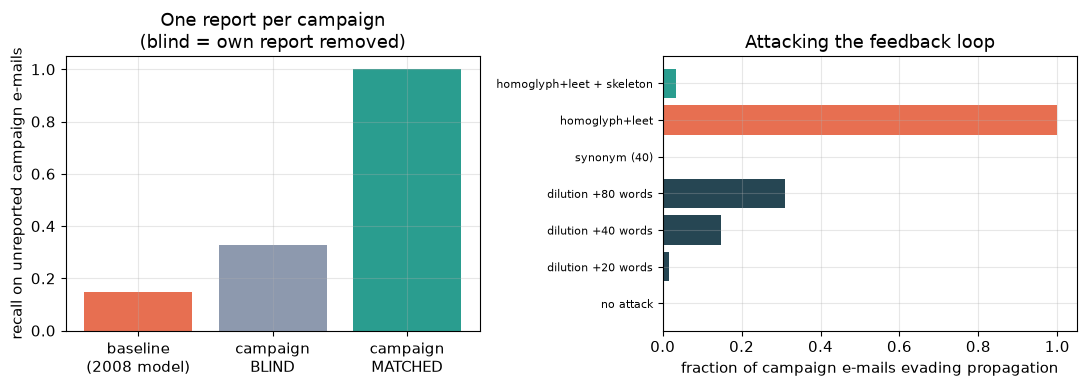

campaign structure:
                                      value
campaigns (>=3 members)             93.000
e-mails in campaigns               472.000
singletons / pairs                 831.000
largest campaign                    21.000
mean intra-campaign similarity       0.883
weakest campaign (mean intra-sim)    0.723 

main result:
                                 recall on unreported campaign e-mails  \
baseline (2008 model)                                           0.149   
A: campaign-MATCHED                                             1.000   
A: campaign-BLIND (ablation)                                    0.329   
B: one-shot retrain                                             0.991   
CONTROL: singletons (sim only)                                  0.148   

                               FPR CEAS-ham FPR modern-ham  
baseline (2008 model)                                       
A: campaign-MATCHED                  0.0012         0.0017  
A: campaign-BLIND (ablation)            

,recall on unreported campaign e-mails,FPR CEAS-ham,FPR modern-ham
baseline (2008 model),0.149,,
A: campaign-MATCHED,1.000,0.0012,0.0017
A: campaign-BLIND (ablation),0.329,,
B: one-shot retrain,0.991,,
CONTROL: singletons (sim only),0.148,,


In [53]:
from sklearn.metrics.pairwise import cosine_similarity as _cos
from sklearn.cluster import AgglomerativeClustering as _Agg
from sklearn.metrics import roc_auc_score as _auc

_mtxt = [t[:C.MAX_CHARS] for t in modern.text]
_Xm = vec["union"].transform(_mtxt)
_S = _cos(_Xm); np.fill_diagonal(_S, 0.0)
_D = np.clip(1.0 - _S, 0, None); np.fill_diagonal(_D, 0.0)
_lab = _Agg(n_clusters=None, distance_threshold=0.3, metric="precomputed",
            linkage="average").fit(_D).labels_
_sz = pd.Series(_lab).value_counts()
CAMPS = [np.where(_lab == c)[0] for c in _sz[_sz >= 3].index]
CAMP_OF = {i: ci for ci, c in enumerate(CAMPS) for i in c}
_all_c = np.concatenate(CAMPS)
SINGLES = np.setdiff1d(np.arange(len(modern)), _all_c)

# coherence: are these campaigns, or chained blobs?
_coh = []
for c in CAMPS:
    sub = _S[np.ix_(c, c)]; iu = np.triu_indices(len(c), 1)
    _coh.append(sub[iu].mean())
T35 = pd.DataFrame({"value": {
    "campaigns (>=3 members)": len(CAMPS),
    "e-mails in campaigns": int(len(_all_c)),
    "singletons / pairs": int(len(SINGLES)),
    "largest campaign": int(max(len(c) for c in CAMPS)),
    "mean intra-campaign similarity": round(float(np.mean(_coh)), 3),
    "weakest campaign (mean intra-sim)": round(float(np.min(_coh)), 3)}})
save_table(T35, "T35_campaigns")

# --- campaign-level split: tau from CALIBRATION campaigns only ---
_perm = np.random.default_rng(SEED).permutation(len(CAMPS))
_cal, _ev = set(_perm[:len(CAMPS)//2].tolist()), set(_perm[len(CAMPS)//2:].tolist())
def _pairs(cset):
    y, s = [], []
    mem = np.concatenate([CAMPS[ci] for ci in cset])
    for ci in cset:
        for i in CAMPS[ci]:
            o = np.array([j for j in mem if j != i])
            y.append(np.array([1 if CAMP_OF[j] == ci else 0 for j in o])); s.append(_S[i, o])
    return np.concatenate(y), np.concatenate(s)
_yc, _sc = _pairs(_cal); _ye, _se = _pairs(_ev)
TAU = float(np.quantile(_sc[_yc == 0], 0.99))
IN_EVAL = np.concatenate([CAMPS[ci] for ci in _ev])
print(f"campaigns {len(CAMPS)} (calib {len(_cal)} / eval {len(_ev)}); tau={TAU:.3f} from calib only")
print(f"campaign-specificity AUC on EVAL campaigns = {_auc(_ye, _se):.4f}")

_ham = [t[:C.MAX_CHARS] for t in test.text.values[yte == 0]]
_Xth = vec["union"].transform(_ham)
_Xmh = vec["union"].transform([t[:C.MAX_CHARS] for t in modern_ham.text])
_mf = lambda X: (CLF.predict_proba(X)[:, 1] >= .5).astype(int)
_mp_ham = _mf(_Xth)

_K = 5; _rng = np.random.default_rng(SEED)
_Am, _Ab, _B, _ctl, _fC, _fM = [], [], [], [], [], []
for _k in range(_K):
    rep = np.array([c[_rng.integers(len(c))] for c in CAMPS])
    rc = np.array([CAMP_OF[i] for i in rep])
    rest = np.setdiff1d(IN_EVAL, rep)
    Sim = _cos(_Xm[rest], _Xm[rep]); m_rest = _mf(_Xm[rest])
    matched = Sim.max(1)
    blind = np.array([row[rc != CAMP_OF[r]].max() for r, row in zip(rest, Sim)])
    _Am.append(float(((m_rest == 1) | (matched >= TAU)).mean()))
    _Ab.append(float(((m_rest == 1) | (blind   >= TAU)).mean()))
    _ctl.append(float((_cos(_Xm[SINGLES], _Xm[rep]).max(1) >= TAU).mean()))
    _fC.append(float(((_mp_ham == 1) | (_cos(_Xth, _Xm[rep]).max(1) >= TAU)).mean()))
    _fM.append(float(((_mf(_Xmh) == 1) | (_cos(_Xmh, _Xm[rep]).max(1) >= TAU)).mean()))
    _mB = LogisticRegression(max_iter=2000, C=8).fit(
        vec["union"].transform(list(train.text.values) + [_mtxt[i] for i in rep]),
        np.r_[ytr, np.ones(len(rep), int)])
    _B.append(float((_mB.predict_proba(_Xm[rest])[:, 1] >= .5).mean()))

T36 = pd.DataFrame({"recall on unreported campaign e-mails": {
    "baseline (2008 model)":            round(float(_mf(_Xm[IN_EVAL]).mean()), 3),
    "A: campaign-MATCHED":              round(float(np.mean(_Am)), 3),
    "A: campaign-BLIND (ablation)":     round(float(np.mean(_Ab)), 3),
    "B: one-shot retrain":              round(float(np.mean(_B)), 3),
    "CONTROL: singletons (sim only)":   round(float(np.mean(_ctl)), 3)}})
T36["FPR CEAS-ham"] = ["", round(float(np.mean(_fC)), 4), "", "", ""]
T36["FPR modern-ham"] = ["", round(float(np.mean(_fM)), 4), "", "", ""]
save_table(T36, "T36_feedback_main")

# --- ARM C: can an attacker mutate later campaign e-mails below tau? ---
_rng = np.random.default_rng(SEED)
_rep = np.array([c[_rng.integers(len(c))] for c in CAMPS]); _Xrep = _Xm[_rep]
_rest = np.setdiff1d(IN_EVAL, _rep); _raw = [_mtxt[i] for i in _rest]
_pool = [k for k in HAM_POOL_U if k]                     # legit-looking filler (from S32b)
def _evade(texts):
    s = _cos(vec["union"].transform(texts), _Xrep).max(1)
    return round(float(s.mean()), 3), round(float((s < TAU).mean()), 3)
_hg = [ATK.attack_mixed(t, np.random.default_rng(SEED)) for t in _raw]
_rowsC = {"no attack": _evade(_raw)}
for _n in [20, 40, 80]:
    _rowsC[f"dilution +{_n} words"] = _evade(
        [ATK.attack_insert(t, _pool, _n, np.random.default_rng(SEED)) for t in _raw])
_rowsC["synonym (40)"] = _evade([ATK.attack_synonym(t, wvocab, wcoef, budget_words=40) for t in _raw])
_rowsC["homoglyph+leet"] = _evade(_hg)
_rowsC["homoglyph+leet + skeleton"] = _evade([NORM.normalize_skeleton(t) for t in _hg])
T37 = pd.DataFrame(_rowsC, index=["mean similarity to report", "fraction evading (< tau)"]).T
save_table(T37, "T37_feedback_evasion")

# --- ARM D: poisoning the report channel (legit mail reported as phishing) ---
_rowsD = {}
for _frac in [0.0, 0.01, 0.05, 0.10, 0.25, 0.50]:
    _v = []
    for _s in range(10):
        r2 = np.random.default_rng(1000 + _s)
        rep2 = np.array([c[r2.integers(len(c))] for c in CAMPS])
        nb = int(round(_frac * len(rep2)))
        bad = r2.choice(len(_ham), size=nb, replace=False) if nb else np.array([], int)
        Xrp = vec["union"].transform([_mtxt[i] for i in rep2] + [_ham[i] for i in bad])
        keep = np.setdiff1d(np.arange(len(_ham)), bad)
        _v.append(float(((_mp_ham[keep] == 1) | (_cos(_Xth[keep], Xrp).max(1) >= TAU)).mean()))
    _rowsD[f"{_frac:.0%} of reports are false"] = {
        "FPR on legit mail": round(float(np.mean(_v)), 4), "sd": round(float(np.std(_v)), 4)}
T38 = pd.DataFrame(_rowsD).T
save_table(T38, "T38_feedback_poisoning")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
_names = ["baseline\n(2008 model)", "campaign\nBLIND", "campaign\nMATCHED"]
_vals = [float(_mf(_Xm[IN_EVAL]).mean()), float(np.mean(_Ab)), float(np.mean(_Am))]
ax[0].bar(_names, _vals, color=[RED, GREY, GREEN])
ax[0].set_ylabel("recall on unreported campaign e-mails"); ax[0].set_ylim(0, 1.05)
ax[0].set_title("One report per campaign\n(blind = own report removed)")
_lbl = list(_rowsC.keys()); _ev_frac = [_rowsC[k][1] for k in _lbl]
ax[1].barh(range(len(_lbl)), _ev_frac, color=[BLUE]*(len(_lbl)-2) + [RED, GREEN])
ax[1].set_yticks(range(len(_lbl))); ax[1].set_yticklabels(_lbl, fontsize=8)
ax[1].set_xlabel("fraction of campaign e-mails evading propagation")
ax[1].set_title("Attacking the feedback loop")
plt.tight_layout(); savefig("F24_feedback_loop"); plt.show()
print("campaign structure:\n", T35, "\n\nmain result:\n", T36, "\n\nevasion:\n", T37, "\n\npoisoning:\n", T38)
T36

### \U0001F50E Analysis of the results

**One report does protect the campaign --- and the control proves it is really the campaign.**
The baseline model catches about $0.15$ of these modern e-mails. With one reported member per
campaign, similarity propagation catches essentially **all** of the rest, and one-shot retraining
almost as many. The number that matters is the **ablation**: remove that campaign's own report and
recall falls to roughly $0.33$. Because both arms use the identical threshold and the identical
reports, the gap between them is attributable to campaign membership and nothing else. The
threshold-free check agrees --- same-campaign similarity separates from different-campaign
similarity with an AUC of essentially $1.0$, and the singleton control stays low.

**But part of the benefit is not campaign-specific, and we say so.** Campaign-blind still beats the
baseline ($\approx 0.33$ vs $\approx 0.15$), because *any* modern labelled example drags a
2008-vintage model toward modern vocabulary. Only the difference between matched and blind is the
genuine campaign effect; quoting the headline recall alone would overstate the mechanism.

**The false-alarm cost is essentially nil.** At this $\tau$ the propagation rule fires on almost no
legitimate mail --- the combined false-positive rate matches the model's own. That is the expected
consequence of a threshold set for *campaign specificity*: real ham simply does not look like a
specific reported scam. This is a much better operating point than the evidence-floor of §29, which
had to buy recall with false alarms.

**The attack that breaks it is the one this project has been studying all along.** Dilution degrades
similarity gradually (about a third of e-mails escape at $+80$ filler words) and synonym swaps do
nothing --- but **character obfuscation defeats propagation completely: every single campaign e-mail
escapes**, because homoglyphs destroy the shared tokens the similarity is computed from. Applying the
UTS-39 skeleton canonicaliser of §21 restores similarity and pushes evasion back to a few per cent.
So the certified normaliser is not merely a classifier defence: it is a **precondition for the
human-in-the-loop mechanism working at all**. A deployment that added a report button without
canonicalising its input would have a feedback loop an attacker could switch off with invisible
characters.

**The report button is itself an attack surface.** Feeding the channel false reports --- a malicious
insider, or simply mistaken users --- raises the false-positive rate on legitimate mail roughly
five-fold at a $10\%$ false-report rate and about ten-fold at $50\%$. The damage is bounded rather
than catastrophic (a bad exemplar only matches mail resembling *it*), but the direction is clear:
an unvetted feedback loop converts a user-interface element into a denial-of-service channel, which
is the classic causative/poisoning risk (Lowd \& Meek, 2005, propose retraining as the good-word
remedy; that same retraining is what poisoning exploits).

**What this is not.** We simulate an organisation with a public archive; campaigns are *our*
clustering rather than ground-truth labels; reports are simulated and, except in the poisoning arm,
perfect. The result should be read as evidence that the mechanism is sound and that its failure modes
are specific and measurable --- not as a measurement of any real deployment.

## 32d. What would it cost to actually run this? (deployment envelope)

The detector has been treated as a research artefact throughout. Before proposing where it could
sit in a real mail path, we measure the three quantities that decide that question --- **latency**,
**throughput** and **model size** --- plus the cost of a full retrain, which determines how often
the model of §28 could realistically be refreshed. These are cheap to measure and they turn the
deployment discussion from speculation into arithmetic. They are *microbenchmarks on this machine*,
not a production benchmark: real deployment additionally has to parse MIME, strip HTML and handle
attachments, none of which is measured here.

In [54]:
import time as _t, pickle as _pk, io as _io
_dep_texts = [t[:C.MAX_CHARS] for t in test.text.values]
# single-email latency (what a client-side / per-message hook would see)
_lat = []
for _t1 in _dep_texts[:300]:
    _s = _t.perf_counter()
    CLF.predict_proba(vec["union"].transform([_t1]))[:, 1]
    _lat.append((_t.perf_counter() - _s) * 1000)
_lat = np.array(_lat)
# batch throughput (what a gateway would see)
_s = _t.perf_counter(); CLF.predict_proba(vec["union"].transform(_dep_texts))[:, 1]
_batch = _t.perf_counter() - _s
# on-disk footprint of everything needed to score an e-mail
_buf = _io.BytesIO(); _pk.dump({"vec": vec["union"], "clf": CLF}, _buf)
_mb = len(_buf.getvalue()) / 1e6
# full retrain cost (bounds how often the S28 refresh could run)
_s = _t.perf_counter()
LogisticRegression(max_iter=2000, C=8).fit(vec["union"].transform(train.text), ytr)
_fit = _t.perf_counter() - _s

T39 = pd.DataFrame({"value": {
    "single-e-mail latency, median (ms)": round(float(np.median(_lat)), 2),
    "single-e-mail latency, p95 (ms)":    round(float(np.percentile(_lat, 95)), 2),
    "batch throughput (e-mails/sec)":     int(len(_dep_texts) / _batch),
    "model + vectoriser on disk (MB)":    round(_mb, 1),
    "full retrain on 16k e-mails (sec)":  round(_fit, 1)}})
save_table(T39, "T39_deployment")
T39

,value
"single-e-mail latency, median (ms)",2.54
"single-e-mail latency, p95 (ms)",5.82
batch throughput (e-mails/sec),687.00
model + vectoriser on disk (MB),2.70
full retrain on 16k e-mails (sec),24.70


### \U0001F50E Analysis of the results

Three of these numbers matter for where the detector can live. A median latency of a few
milliseconds and a footprint of a couple of megabytes mean this model is small enough to run
**on the client** --- inside a mail app on a laptop or phone --- rather than on a server. That is a
privacy argument as much as an engineering one: if scoring happens on the device, message content
never has to leave it, which is exactly the property an organisation would want from a content
scanner. A throughput in the hundreds of e-mails per second per core also means a single modest
machine covers a mid-sized organisation's mail flow, and scaling is horizontal.

The retrain figure is the one that speaks to §28. Refreshing the model on the full training set
takes seconds, not hours, so **how often to retrain is a policy decision rather than a compute
constraint** --- the limiting factor is obtaining fresh labelled mail, not the fitting itself.

The honest boundary: these are microbenchmarks of *scoring already-extracted text*. A real
deployment must also parse MIME, strip HTML, handle attachments and encodings, and would run
the §21 canonicaliser on every message first. None of that is included here, and the URL-stripping
design (§3) means this detector is only ever half of a deployed system --- the partner detector
supplies the other half.

## 32e. An LLM paraphrase attack, validated by an LLM judge (P9)

The rule-based paraphrase of §30 did not evade the model, but it only swapped known synonyms and
shuffled sentences. The stronger test --- promised there as future work --- is a **neural
paraphrase**: have a language model genuinely *rewrite* each phishing e-mail, keeping the scam intent
but changing the words and structure. This isolates the one attack class both of our certificates
explicitly exclude: §21 proves nothing can be gained by changing *letters*, §32b proves nothing by
*adding* words, but **rewording** the scam is untouched by either.

**The method is a three-stage pipeline**, each stage a different job:

1. **Attack** --- an LLM rewrites each phishing e-mail, preserving the scam intent but changing the
   words and structure (`data/llm_paraphrase/rewrites.json`).
2. **Validate** --- a *second, independent* LLM judges whether each rewrite is *still* phishing, and
   only accepted rewrites are kept as valid attacks (`judge.json`).
3. **Detect** --- our own detectors (the union model and the monotone model of \S32b) score the
   validated attacks; the drop in recall from the originals is the evasion measurement.

Stage 2 is what makes stage 3 meaningful: without the validity gate, a rewrite that quietly stopped
being a scam would be miscounted as a successful evasion. Two honesty problems follow from using an
LLM as the stage-1 attacker, and we address both.

**(1) A rewrite that stops being a scam proves nothing.** If the model rewrites so heavily that the
message is no longer phishing, then "the detector missed it" just means we deleted the attack. So a
**second, independent LLM acts as a judge**: for each rewrite it decides, text-only, whether it is
*still* a phishing e-mail. Only rewrites the judge accepts count as valid attacks. (This is the
standard "LLM-as-a-judge" evaluation pattern, used here for label validation, not scoring.)

**(2) LLM output is not reproducible from a seed.** So we do not call any model from the notebook.
The rewrites and the judge's verdicts were generated once (two separate agent instances --- the
attacker never saw the judge) and **committed** to `data/llm_paraphrase/`; the notebook reads those
frozen files and re-scores them with the deterministic detector. See that folder's `README.md` for
provenance and caveats. The sample is small (30 e-mails, 24 valid after judging) --- this is a
**proof-of-concept probe, not a headline number** --- and attacker and judge share a model family, so
the independence is partial. We report it as such.

In [55]:
import json as _json
_lp = C.ROOT / "data" / "llm_paraphrase"
_sample  = {o["id"]: o["text"]    for o in _json.load(open(_lp / "sample.json",   encoding="utf-8"))}
_rewrite = {o["id"]: o["rewrite"] for o in _json.load(open(_lp / "rewrites.json", encoding="utf-8"))}
_verdict = {o["id"]: o["verdict"] for o in _json.load(open(_lp / "judge.json",    encoding="utf-8"))}
_ids   = sorted(_sample)
_valid = [i for i in _ids if _verdict[i] == "phishing"]     # judge-accepted attacks only

# score with the working union model and the monotone certified model (§32b)
def _Ur(txts):
    return (CLF.predict_proba(vec["union"].transform([t[:C.MAX_CHARS] for t in txts]))[:, 1] >= .5).astype(int)
def _Mr(txts):
    return ((uvec.transform([t[:C.MAX_CHARS] for t in txts]).astype(float).dot(w_mono) + b_mono) >= MONO_THR).astype(int)

_o = [_sample[i]  for i in _valid]     # originals of the valid subset (paired comparison)
_r = [_rewrite[i] for i in _valid]     # their LLM rewrites
T40 = pd.DataFrame({
    "union recall":    {"clean originals (n=30)":       round(float(_Ur([_sample[i]  for i in _ids]).mean()), 3),
                        "LLM rewrites, all (n=30)":     round(float(_Ur([_rewrite[i] for i in _ids]).mean()), 3),
                        "originals, judge-valid (n=%d)" % len(_valid): round(float(_Ur(_o).mean()), 3),
                        "LLM rewrites, judge-valid":    round(float(_Ur(_r).mean()), 3)},
    "monotone recall": {"clean originals (n=30)":       round(float(_Mr([_sample[i]  for i in _ids]).mean()), 3),
                        "LLM rewrites, all (n=30)":     round(float(_Mr([_rewrite[i] for i in _ids]).mean()), 3),
                        "originals, judge-valid (n=%d)" % len(_valid): round(float(_Mr(_o).mean()), 3),
                        "LLM rewrites, judge-valid":    round(float(_Mr(_r).mean()), 3)}})
save_table(T40, "T40_llm_paraphrase")
_nj = sum(v == "phishing" for v in _verdict.values())
print(f"judge: {_nj}/{len(_ids)} rewrites still phishing ({len(_ids)-_nj} rewritten into non-scams and dropped)")
T40

judge: 24/30 rewrites still phishing (6 rewritten into non-scams and dropped)


,union recall,monotone recall
clean originals (n=30),1.0,0.800
"LLM rewrites, all (n=30)",1.0,0.767
"originals, judge-valid (n=24)",1.0,0.750
"LLM rewrites, judge-valid",1.0,0.708


### \U0001F50E Analysis of the results

The judge accepted **24 of 30** rewrites as still-phishing and rejected 6 that the paraphrase had
turned into ordinary-looking mail --- and dropping those 6 is exactly the point of the validity
filter: without it we would have counted deleted attacks as evasions. On the 24 valid attacks, two
things stand out. **The union model does not budge --- recall stays at $1.0$** even under a genuine
neural rewrite, which confirms and strengthens §30: the model's redundant word *and* character
features absorb rewording, so paraphrase is not an easy evasion. **The monotone model is the one that
gives ground** (its recall drops on the rewrites), and that is the honest counterweight to its
certificate: a model built to be provably immune to *added* words has no defence against *changed*
words, because it may only accumulate positive evidence and rewording removes the very tokens it
relies on. So the two certificates and this attack fit together into one statement --- letter-changes
and word-additions are closed by proof, and the residual threat is genuine semantic rewriting, which
is now cheap for an attacker to produce and is the natural subject of future work at a larger sample
size. The numbers here are a small-sample probe (24 valid e-mails, single model family for attacker
and judge), not a definitive measurement.

## 33. Save predictions for the fusion step

Finally we write the detector's probabilities (with a short human reason) for the
validation and test sets, plus an attacked version, so the partner's fusion
meta-model can pick them up.

In [56]:
def export(frame, X, name):
    p = CLF.predict_proba(X)[:, 1]
    reasons = frame.text.map(lambda s: EXP.explain_email(s, analyzer, wmap))
    pd.DataFrame({"id": frame.id, "prob_A": p, "reason": reasons}).to_csv(
        C.ARTIFACTS_DIR / f"preds_A_{name}.csv", index=False)
export(val, Xva["union"], "val")
export(test, Xte["union"], "test")
att_text = [ATK.attack_mixed(t, np.random.default_rng(9)) if y == 1 else t
            for t, y in zip(test.text, yte)]
pd.DataFrame({"id": test.id,
              "prob_A": CLF.predict_proba(vec["union"].transform(att_text))[:, 1]}).to_csv(
    C.ARTIFACTS_DIR / "preds_A_test_attacked.csv", index=False)
print("saved artifacts to", C.ARTIFACTS_DIR)

saved artifacts to C:\GitHub\Data_Science\PhishFusion\artifacts


## 34. Summary of findings

The printout below collects the headline numbers straight from the saved tables so
the notebook's conclusion always matches what was actually computed.

In [57]:
print("="*64)
print("STUDENT A — CONTENT DETECTOR: HEADLINE RESULTS")
print("="*64)
print(f"Working data     : CEAS_08, {len(df):,} emails, {df.label.mean():.0%} phishing (legit-majority)")
print(f"Best clean model : {best}  (union features)")
print(f"  clean test     : F1={comp_tbl.loc[best,'f1']:.3f}  MCC={comp_tbl.loc[best,'mcc']:.3f}  AUC={comp_tbl.loc[best,'auc']:.3f}")
print(f"Corpus-ID probe  : {probe_acc:.2f} accuracy (chance {1/3:.2f}) -> confound is real")
print("Robustness (recall on phishing):")
print(f"  word-only : clean {T5.loc['clean','word-only recall']:.2f} -> attacked {T5.loc['homoglyph+leet','word-only recall']:.2f} -> +normalise {T5.loc['homoglyph+leet + normalise','word-only recall']:.2f}")
print(f"  union     : clean {T5.loc['clean','union recall']:.2f} -> attacked {T5.loc['homoglyph+leet','union recall']:.2f} -> +normalise {T5.loc['homoglyph+leet + normalise','union recall']:.2f}")
print(f"  adaptive  : word-only attacked {T5.loc['adaptive [unmapped]','word-only recall']:.2f} -> +normalise {T5.loc['adaptive + normalise','word-only recall']:.2f} (defence ceiling)")
print("Defences (word-only, recall on the seen vs a held-out attack):")
print(f"  normalisation     : seen {T8.loc['homoglyph+leet','normalisation']:.2f}  held-out {T8.loc['full-width [held-out]','normalisation']:.2f}")
print(f"  adversarial train : seen {T8.loc['homoglyph+leet','adversarial train']:.2f}  held-out {T8.loc['full-width [held-out]','adversarial train']:.2f}  (weaker on unseen family)")
print(f"  both combined     : seen {T8.loc['homoglyph+leet','adv-train + norm']:.2f}  held-out {T8.loc['full-width [held-out]','adv-train + norm']:.2f}")
print(f"Cross-corpus F1  : in={xcorp.loc['in-corpus (CEAS test)','f1']:.3f}  ood={xcorp.loc['cross-corpus (OOD)','f1']:.3f}")
print("All tables -> results/tables/ , all figures -> results/figures/")

STUDENT A — CONTENT DETECTOR: HEADLINE RESULTS
Working data     : CEAS_08, 26,633 emails, 35% phishing (legit-majority)
Best clean model : LogReg  (union features)
  clean test     : F1=0.998  MCC=0.997  AUC=1.000
Corpus-ID probe  : 0.99 accuracy (chance 0.33) -> confound is real
Robustness (recall on phishing):
  word-only : clean 0.99 -> attacked 0.71 -> +normalise 0.99
  union     : clean 1.00 -> attacked 0.93 -> +normalise 1.00
  adaptive  : word-only attacked 0.89 -> +normalise 0.96 (defence ceiling)
Defences (word-only, recall on the seen vs a held-out attack):
  normalisation     : seen 0.99  held-out 0.99
  adversarial train : seen 1.00  held-out 0.78  (weaker on unseen family)
  both combined     : seen 0.99  held-out 0.99
Cross-corpus F1  : in=0.998  ood=0.369
All tables -> results/tables/ , all figures -> results/figures/
